# Hooplytics Powered by Python

**Author:** Chris Campbell  
**Stack:** `nba_api` · `pandas` · `scikit-learn` · `seaborn` · `plotly`  
**Python:** 3.11+

`hooplytics` is the Python port of [hooplyticsR](https://github.com/texasbe2trill/hooplyticsR). It analyzes NBA player performance using descriptive statistics, distributional visualizations, and supervised machine-learning models trained on historical box scores.

This notebook is organized as a narrative report:

1. **Setup & data ingestion** — pull per-game logs from the official NBA Stats API.
2. **Player statistics** — averages, standard deviations, and a fantasy score.
3. **Performance visualizations** — faceted histograms, KDEs, and an interactive radar.
4. **Predictive modeling** — kNN and Random Forest regressors with cross-validated tuning.
5. **Fantasy decisions** — combine projections with model predictions to produce More/Less calls.


## 1. Setup

We'll fetch each player's regular-season game logs season-by-season via [`nba_api`](https://github.com/swar/nba_api) and cache results to disk so re-runs don't hit the network.

In [1]:
# ── Package bootstrap ─────────────────────────────────────────────────────────
# Checks whether each required package is importable and installs any that are
# missing. Uses %pip (via IPython) rather than subprocess so that newly installed
# packages are immediately visible to the running kernel — no restart required.
# No-op in a local venv where everything is already installed.
import importlib.util
import sys

_REQUIRED = [
    ("nba_api",     "nba_api>=1.4.1"),
    ("pandas",      "pandas>=2.2"),
    ("numpy",       "numpy>=2.1"),
    ("sklearn",     "scikit-learn>=1.5"),
    ("matplotlib",  "matplotlib>=3.9"),
    ("seaborn",     "seaborn>=0.13"),
    ("plotly",      "plotly>=5.24"),
    ("pyarrow",     "pyarrow>=17.0"),
    ("tqdm",        "tqdm>=4.66"),
    ("ipywidgets",  "ipywidgets>=8.1"),
]

_missing = [pkg for mod, pkg in _REQUIRED if importlib.util.find_spec(mod) is None]

if _missing:
    print(f"Installing: {', '.join(_missing)}")
    # get_ipython().run_line_magic("pip", ...) is equivalent to %pip install.
    # Unlike subprocess, it updates sys.path in the current process so imports
    # work in the very next cell without a kernel restart.
    get_ipython().run_line_magic("pip", f"install -q {' '.join(_missing)}")  # noqa: F821  # type: ignore[name-defined]
    print("✅ Done — packages installed.")
else:
    print("✅ All packages present.")


✅ All packages present.


In [2]:
from __future__ import annotations

import os
import re
import sys
import time
import warnings
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RepeatedKFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from nba_api.stats.endpoints import playergamelog
from nba_api.stats.static import players as nba_players

# typing.NotRequired requires 3.11+; 3.14 was used during development.
if sys.version_info < (3, 11):
    raise RuntimeError(f"Python 3.11+ required, got {sys.version}")

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="talk")
RNG = np.random.default_rng(123)

CACHE_DIR = Path("data/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Odds API setup ─────────────────────────────────────────────────────────────
# Defined here (before §4.3) so the decision engine can use live sportsbook lines
# rather than the widget projections you typed in §1.1.
#
# Key resolution order (first match wins):
#   1. Colab Secrets (google.colab.userdata)  — auto-detected, no file needed
#   2. .env file in project root              — gitignored, copy .env.example
#   3. Shell environment variable             — export ODDS_API_KEY=... before jupyter
# Never hard-code the key — .ipynb files are JSON and keys survive in git history.

def _load_dotenv(path: Path = Path(".env")) -> None:
    """Tiny zero-dependency .env loader. Lines like `KEY=value` populate os.environ.
    .env wins over any pre-existing shell env value so rotating the key in .env
    actually takes effect on the next imports-cell re-run (otherwise a stale
    ODDS_API_KEY exported in your shell would silently shadow the new one).
    """
    if not path.exists():
        return
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key, value = key.strip(), value.strip().strip('"').strip("'")
        os.environ[key] = value


def _load_colab_secret(secret_name: str = "ODDS_API_KEY") -> None:
    """If running on Google Colab, pull the secret from Colab Secrets into os.environ."""
    try:
        from google.colab import userdata  # type: ignore
        value = userdata.get(secret_name)
        if value:
            os.environ.setdefault(secret_name, value)
    except Exception:
        pass  # Not on Colab or secret not set — fall through to .env / env var


_load_colab_secret()
_load_dotenv()
ODDS_API_KEY: str = os.getenv("ODDS_API_KEY", "").strip()

# The Odds API market name → our model name. Add/remove rows to control coverage.
ODDS_MARKETS: dict[str, str] = {
    "player_points":   "points",
    "player_rebounds": "rebounds",
    "player_assists":  "assists",
    "player_threes":   "threepm",
}
ODDS_BASE = "https://api.the-odds-api.com/v4/sports/basketball_nba"


def _canon_name(s: str) -> str:
    """Canonical player name for fuzzy matching — strips all non-alpha chars and lowercases.
    e.g. 'Shai Gilgeous-Alexander' and 'Shai Gilgeous Alexander' both become
    'shaigilgeousalexander', handling the hyphen-vs-space variation some books use.
    """
    return re.sub(r"[^a-z]", "", s.lower())


# Where to stash the raw per-event odds payloads on disk. Each /events/{id}/odds
# call costs quota, so we cache the JSON for the day and re-filter locally on
# subsequent calls (e.g. when adding a new player to the roster).
ODDS_CACHE_DIR = CACHE_DIR / "odds"
ODDS_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _odds_cache_path(date_str: str) -> Path:
    return ODDS_CACHE_DIR / f"nba_player_props_{date_str}.json"


def _log_odds_quota(resp: requests.Response) -> None:
    """Surface the remaining quota from response headers so it's easy to monitor.
    The Odds API returns x-requests-remaining and x-requests-used on every call.
    """
    used = resp.headers.get("x-requests-used")
    remaining = resp.headers.get("x-requests-remaining")
    last_cost = resp.headers.get("x-requests-last")
    if remaining is not None:
        print(f"  Odds API quota: {remaining} remaining (used {used}, this call cost {last_cost})")


def _fetch_odds_payload(api_key: str, force_refresh: bool = False) -> list[dict]:
    """Fetch (or load from cache) today's full per-event player-prop payload.

    Each entry in the returned list is the raw JSON for one event's /odds endpoint.
    Cache key is the current local date — re-runs within the same day are free.
    Set force_refresh=True to bypass the cache and re-hit the API.
    """
    import json
    from datetime import date

    cache_path = _odds_cache_path(date.today().isoformat())

    if cache_path.exists() and not force_refresh:
        try:
            with cache_path.open("r") as f:
                cached = json.load(f)
            print(f"  Odds API: using cached lines from {cache_path.name} (no API calls)")
            return cached
        except Exception as exc:  # noqa: BLE001
            print(f"  ! odds cache unreadable, refetching: {exc}")

    # ── 1. Fetch today's event list (free — doesn't count against quota) ──────
    events_resp = requests.get(
        f"{ODDS_BASE}/events", params={"apiKey": api_key}, timeout=15
    )
    # Hand-roll error handling so the apiKey in the URL never leaks via
    # requests' default HTTPError message (which includes the full URL).
    if events_resp.status_code == 401:
        raise RuntimeError(
            "Odds API 401 Unauthorized — the key in .env is invalid or revoked. "
            "Re-run the imports cell after updating .env so the new key is loaded."
        )
    if events_resp.status_code == 429:
        raise RuntimeError("Odds API 429 — monthly quota exhausted.")
    if not events_resp.ok:
        raise RuntimeError(
            f"Odds API /events returned HTTP {events_resp.status_code} "
            f"(key redacted from error message)."
        )
    events = events_resp.json()
    if not isinstance(events, list):
        # Don't echo the payload — error responses from the API can include the key.
        raise RuntimeError("Odds API error — check your key, quota, and network.")

    print(f"  Odds API: {len(events)} NBA game(s) on the schedule "
          f"(this will use ~{len(events) * len(ODDS_MARKETS)} quota credits)")
    if not events:
        with cache_path.open("w") as f:
            json.dump([], f)
        return []

    payload: list[dict] = []
    last_resp: requests.Response | None = None
    for ev in events:
        matchup = f"{ev.get('away_team', '?')} @ {ev.get('home_team', '?')}"
        try:
            resp = requests.get(
                f"{ODDS_BASE}/events/{ev['id']}/odds",
                params={
                    "apiKey": api_key,
                    "regions": "us",
                    "markets": ",".join(ODDS_MARKETS),
                    "oddsFormat": "american",
                },
                timeout=15,
            )
            if resp.status_code == 401:
                print(
                    "  ! Odds API 401 Unauthorized — player prop markets require a "
                    "paid tier (see https://the-odds-api.com/#get-access). "
                    "Falling back to season-average lines."
                )
                return []
            if resp.status_code == 429:
                print("  ! Odds API 429 quota exhausted — falling back to cached/default lines.")
                return payload  # return what we have so far
            resp.raise_for_status()
            payload.append({
                "matchup": matchup,
                "away_team": ev.get("away_team"),
                "home_team": ev.get("home_team"),
                "props": resp.json(),
            })
            last_resp = resp
        except KeyboardInterrupt:
            raise
        except requests.HTTPError as exc:
            status = exc.response.status_code if exc.response is not None else "?"
            print(f"  ! skipping {matchup}: HTTP {status}")
            continue
        except Exception as exc:  # noqa: BLE001
            print(f"  ! skipping {matchup}: {type(exc).__name__}: {exc}")
            continue

    if last_resp is not None:
        _log_odds_quota(last_resp)

    # Persist to cache so subsequent calls today (e.g. add-player) are free.
    try:
        with cache_path.open("w") as f:
            json.dump(payload, f)
        print(f"  Odds API: cached {len(payload)} event(s) to {cache_path.name}")
    except Exception as exc:  # noqa: BLE001
        print(f"  ! could not write odds cache: {exc}")

    return payload


def fetch_live_player_lines(
    api_key: str,
    roster_players: list[str],
    *,
    force_refresh: bool = False,
) -> pd.DataFrame:
    """Return one row per (player, model_name, line) using the consensus median across books.

    Loads today's per-event player prop payload (from disk cache when available,
    otherwise from the API), then filters locally to ``roster_players`` so adding
    a player to the roster mid-session does NOT cost any additional API quota.
    Player name matching is case- and punctuation-insensitive so e.g.
    'Shai Gilgeous-Alexander' and 'Shai Gilgeous Alexander' both match.
    Returns an empty DataFrame on off-days or when no matching lines are available.
    """
    payload = _fetch_odds_payload(api_key, force_refresh=force_refresh)
    if not payload:
        return pd.DataFrame(columns=["player", "model", "line", "books", "matchup"])

    canon_to_name: dict[str, str] = {_canon_name(p): p for p in roster_players}
    rows: list[dict] = []

    for ev_entry in payload:
        matchup = ev_entry.get("matchup", "?")
        props = ev_entry.get("props", {})
        bucket: dict[tuple[str, str], list[float]] = {}
        for bm in props.get("bookmakers", []):
            for market in bm.get("markets", []):
                model_name = ODDS_MARKETS.get(market["key"])
                if model_name is None:
                    continue
                for o in market.get("outcomes", []):
                    # Per API docs: outcome["name"] is "Over"/"Under";
                    # outcome["description"] holds the player's name.
                    if o.get("name") != "Over":
                        continue
                    api_name = o.get("description", "")
                    if not api_name:
                        continue
                    roster_name = canon_to_name.get(_canon_name(api_name))
                    if roster_name is None:
                        continue
                    bucket.setdefault((roster_name, model_name), []).append(float(o["point"]))

        for (roster_name, model_name), points in bucket.items():
            rows.append({
                "player": roster_name,
                "model": model_name,
                "line": float(np.median(points)),
                "books": len(points),
                "matchup": matchup,
            })

    print(f"  Odds API: {len(rows)} player prop line(s) matched for {len(roster_players)} roster player(s)")
    return pd.DataFrame(rows)


print(f"Python {sys.version.split()[0]}  |  pandas {pd.__version__}  |  numpy {np.__version__}")

Python 3.14.3  |  pandas 3.0.2  |  numpy 2.4.4


### 1.1 Configure your roster

Run the cell below to launch an interactive **roster builder** powered by `ipywidgets` — works in VS Code, JupyterLab, and Google Colab.

**How to use it:**

1. **Pick a season range.** Adjust the *Start year* and *End year* boxes (NBA seasons span two calendar years — *Start year* is the year games tip off, *End year* is the year the season concludes. So `2024 → 2026` covers `2024-25` and `2025-26`; `2025 → 2026` covers only `2025-26`). Default is `2024 → 2026`.
2. **Add players.** Click in the **Add player** box and start typing — the dropdown filters live against every active NBA player. Pick from the menu (or type a full name) and click **Add**. Repeat for every player you want to analyze. The default 6-player roster (LeBron, KD, Wemby, SGA, Chet Holmgren, Ausar Thompson) is pre-loaded — click **Remove** on any row to drop it.
3. **Review projections.** If `ODDS_API_KEY` is set, today's live sportsbook lines are automatically filled in for `points`, `rebounds`, `assists`, and `threepm` wherever available. Otherwise, sensible defaults are shown. Edit any value before clicking Done.
4. **Click ✅ Done — Build roster.** This locks in `ROSTER`, `SEASONS`, `CURRENT`, and `PLAYERS` for the rest of the notebook. Then run §1.2 onward.

> 💡 5-game averages are **auto-derived** from game logs — no manual updates needed. Widget projections are only used in §5 when no live sportsbook line is available.


In [3]:
from typing import NotRequired, TypedDict

import ipywidgets as widgets
from IPython.display import display

from nba_api.stats.static import players as nba_players

# Google Colab needs an explicit opt-in to render ipywidgets >=8 via the
# custom widget manager — without this the cell output is blank.
# No-op (and safely ignored) outside Colab.
try:
    from google.colab import output as _colab_output  # type: ignore
    _colab_output.enable_custom_widget_manager()
except Exception:
    pass


class RosterEntry(TypedDict):
    seasons: list[str]
    proj: NotRequired[dict[str, float]]  # user-supplied baselines per model name


def nba_seasons(start: int, end: int) -> list[str]:
    """Season strings from start year to end year (inclusive end calendar year).
    e.g. nba_seasons(2024, 2026) -> ['2024-25','2025-26']
         nba_seasons(2025, 2026) -> ['2025-26']
    """
    return [f"{y}-{str(y + 1)[-2:]}" for y in range(start, end)]


# Stats that the More/Less engine knows how to project.
PROJ_STATS = ["points", "fantasy_score", "pra", "threepm", "assists"]

# Sensible defaults so users can just hit "Done" without editing anything.
DEFAULT_ROSTER: dict[str, dict[str, float]] = {
    "LeBron James":            {"points": 21.5, "fantasy_score": 41.5, "pra": 34.0, "threepm": 1.5, "assists": 7.0},
    "Kevin Durant":            {"points": 26.0, "fantasy_score": 42.0, "pra": 36.0, "threepm": 2.5, "assists": 4.5},
    "Victor Wembanyama":       {"points": 25.0, "fantasy_score": 53.0, "pra": 39.5, "threepm": 1.5, "assists": 3.0},
    # SGA / Chet / Ausar diversify position and role (lead guard, stretch big, defensive wing)
    # so the noisy assists / stl_blk / tov models have between-player variance to learn from.
    "Shai Gilgeous-Alexander": {"points": 31.0, "fantasy_score": 50.0, "pra": 41.0, "threepm": 2.0, "assists": 6.5},
    "Chet Holmgren":           {"points": 18.0, "fantasy_score": 38.0, "pra": 30.0, "threepm": 1.5, "assists": 2.5},
    "Ausar Thompson":          {"points": 14.5, "fantasy_score": 34.0, "pra": 26.0, "threepm": 0.5, "assists": 3.5},
}

FANTASY_WEIGHTS = dict(pts=1.0, reb=1.2, ast=1.5, stl=3.0, blk=3.0, tov=-1.0)


def fantasy(df: pd.DataFrame) -> pd.Series:
    return sum(df[c] * w for c, w in FANTASY_WEIGHTS.items())  # type: ignore[return-value]


# ── Pre-seed globals so re-running downstream cells without clicking "Done" still works. ──
SEASONS_INPUT: list[str] = nba_seasons(2024, 2026)
CURRENT: list[str] = SEASONS_INPUT
ROSTER: dict[str, RosterEntry] = {
    name: {"seasons": SEASONS_INPUT, "proj": dict(proj)} for name, proj in DEFAULT_ROSTER.items()
}
PLAYERS: list[str] = list(ROSTER)
SEASONS: list[str] = sorted({s for entry in ROSTER.values() for s in entry["seasons"]})

# ── Run-All gate ──────────────────────────────────────────────────────────────
# Set True only when the user clicks "Done" in the widget below. §1.2 checks
# this and aborts (with a friendly message) if the user hit "Run All" without
# confirming their roster — preventing silent runs against stale defaults.
ROSTER_CONFIRMED: bool = False

# ── Roster-builder UI (ipywidgets) ────────────────────────────────────────────
# Combobox.options must be plain strings; we feed it every active NBA player so
# the dropdown filters live as the user types.
_ALL_NBA_PLAYERS: list[dict] = nba_players.get_players()
_ACTIVE_PLAYER_NAMES: list[str] = sorted(
    p["full_name"] for p in _ALL_NBA_PLAYERS if p.get("is_active")
)
_ALL_PLAYER_NAMES: list[str] = sorted(p["full_name"] for p in _ALL_NBA_PLAYERS)

# Working copy that the UI mutates; copied into ROSTER on "Done".
_pending_roster: dict[str, dict[str, float]] = {
    name: dict(proj) for name, proj in DEFAULT_ROSTER.items()
}

# Tracks which (player, stat) values were sourced from live Odds API lines.
# _render_players uses this to show a ✅ badge on live-fetched projection fields.
_live_stats: set[tuple[str, str]] = set()

# ── Live-line prefill ─────────────────────────────────────────────────────────
# When ODDS_API_KEY is set, pull today's consensus lines from The Odds API and
# overwrite matching projection values in _pending_roster so each player row
# starts with the real posted line instead of a static default.
# Only the four stats covered by ODDS_MARKETS (points, rebounds, assists,
# threepm) are touched; fantasy_score and pra keep their hard-coded defaults.
# Silently skips on off-days, network errors, or user interrupts — the widget
# always renders regardless.
_prefill_widget = widgets.HTML()
if ODDS_API_KEY:
    try:
        _init_lines = fetch_live_player_lines(ODDS_API_KEY, list(_pending_roster))
        _filled = 0
        for _, _lr in _init_lines.iterrows():
            for _rname in _pending_roster:
                if _rname.lower() == str(_lr["player"]).lower():
                    _pending_roster[_rname][str(_lr["model"])] = float(_lr["line"])
                    _live_stats.add((_rname, str(_lr["model"])))
                    _filled += 1
                    break
        if _filled:
            _prefill_widget.value = (
                f"<span style='color:#1a6e2e'>✅ {_filled} projection value"
                f"{'s' if _filled != 1 else ''} pre-filled from live Odds API lines."
                f" Fields marked ✅ below reflect today's posted lines."
                f" Edit any value before clicking Done.</span>"
            )
        else:
            _prefill_widget.value = (
                "<span style='color:#888'>ℹ️ Odds API connected but no lines found "
                "for today's games — using default projections.</span>"
            )
    except BaseException as _pe:
        # Catch KeyboardInterrupt (and any other BaseException) so the cell
        # always completes and the widget is always displayed below.
        # Print the full traceback to stdout so the actual error is debuggable.
        import traceback
        print(f"!! Odds API prefill failed: {type(_pe).__name__}: {_pe}")
        traceback.print_exc()
        _prefill_widget.value = (
            f"<span style='color:#888'>ℹ️ Odds API prefill skipped "
            f"({type(_pe).__name__}: {str(_pe)[:200]}) — using default projections.</span>"
        )
else:
    _prefill_widget.value = (
        "<span style='color:#888'>ℹ️ No ODDS_API_KEY set — showing default projections. "
        "Add key to .env for automatic live-line prefill.</span>"
    )


def _update_prefill_banner() -> None:
    """Refresh the live-line count in the banner after each player is added."""
    n = len(_live_stats)
    if n:
        _prefill_widget.value = (
            f"<span style='color:#1a6e2e'>✅ {n} projection value"
            f"{'s' if n != 1 else ''} pre-filled from live Odds API lines."
            f" Fields marked ✅ below reflect today's posted lines."
            f" Edit any value before clicking Done.</span>"
        )
    elif ODDS_API_KEY:
        _prefill_widget.value = (
            "<span style='color:#888'>ℹ️ Odds API connected but no lines found "
            "for today's games — using default projections.</span>"
        )


# ---- widgets ----
_start_year = widgets.BoundedIntText(
    value=2024, min=1946, max=2030, step=1,
    description="Start year:", style={"description_width": "100px"},
    layout=widgets.Layout(width="220px"),
)
_end_year = widgets.BoundedIntText(
    value=2026, min=1947, max=2031, step=1,
    description="End year:", style={"description_width": "100px"},
    layout=widgets.Layout(width="220px"),
)
_player_search = widgets.Combobox(
    placeholder="Type a name (e.g. 'leb' → LeBron James)…",
    options=_ACTIVE_PLAYER_NAMES,
    ensure_option=False,  # allow free-form entry as a fallback
    description="Add player:", style={"description_width": "100px"},
    layout=widgets.Layout(width="540px"),
)
_include_retired = widgets.Checkbox(
    value=False, description="Include retired players in suggestions",
    indent=False, layout=widgets.Layout(width="320px"),
)
_add_btn = widgets.Button(
    description="Add", button_style="primary", icon="plus",
    layout=widgets.Layout(width="100px"),
)
_done_btn = widgets.Button(
    description="✅ Done — Build roster", button_style="success",
    layout=widgets.Layout(width="240px"),
)
_status = widgets.HTML()
_players_box = widgets.VBox()


def _on_include_retired(change):
    _player_search.options = _ALL_PLAYER_NAMES if change["new"] else _ACTIVE_PLAYER_NAMES


_include_retired.observe(_on_include_retired, names="value")


def _render_players() -> None:
    """Re-draw the per-player projection rows from `_pending_roster`."""
    rows: list[widgets.Widget] = []
    for name, proj in _pending_roster.items():
        header = widgets.HTML(f"<b style='font-size:14px'>{name}</b>")
        proj_inputs: list[widgets.Widget] = []
        for stat in PROJ_STATS:
            is_live = (name, stat) in _live_stats
            w = widgets.FloatText(
                value=float(proj.get(stat, 0.0)),
                description=f"✅ {stat}" if is_live else stat,
                step=0.5,
                style={"description_width": "110px" if is_live else "100px"},
                layout=widgets.Layout(width="190px"),
            )

            def _on_change(change, n=name, s=stat):
                _pending_roster[n][s] = float(change["new"])

            w.observe(_on_change, names="value")
            proj_inputs.append(w)

        remove = widgets.Button(
            description="Remove", button_style="warning", icon="trash",
            layout=widgets.Layout(width="110px"),
        )

        def _on_remove(_btn, n=name):
            _pending_roster.pop(n, None)
            _render_players()

        remove.on_click(_on_remove)

        rows.append(widgets.VBox(
            [widgets.HBox([header, remove]), widgets.HBox(proj_inputs)],
            layout=widgets.Layout(border="1px solid #ddd", padding="8px",
                                  margin="4px 0", border_radius="6px"),
        ))
    _players_box.children = tuple(rows)
    _status.value = (
        f"<i>Pending roster ({len(_pending_roster)}):</i> "
        f"{', '.join(_pending_roster) or '<i>empty — add at least one player</i>'}"
    )


def _on_add(_btn) -> None:
    raw = (_player_search.value or "").strip()
    if not raw:
        return

    # Resolve the typed text to a canonical player name.
    pool = _ALL_PLAYER_NAMES if _include_retired.value else _ACTIVE_PLAYER_NAMES
    if raw.endswith("!"):
        name = raw[:-1].strip()  # bypass: trust whatever the user typed
    elif raw in pool:
        name = raw
    else:
        # Fuzzy fallback: first case-insensitive substring match.
        matches = [p for p in pool if raw.lower() in p.lower()]
        if matches:
            name = matches[0]
        else:
            _status.value = (
                f"<span style='color:#c00'>! No NBA player matches "
                f"'<code>{raw}</code>'. Append <code>!</code> to use it as-is.</span>"
            )
            return

    if name and name not in _pending_roster:
        _pending_roster[name] = dict(DEFAULT_ROSTER.get(name, {}))
        # Attempt to prefill live sportsbook lines for the newly added player.
        # Silently falls back to defaults on any error (including interrupts).
        if ODDS_API_KEY:
            try:
                _new_lines = fetch_live_player_lines(ODDS_API_KEY, [name])
                _added = 0
                for _, _lr in _new_lines.iterrows():
                    if str(_lr["player"]).lower() == name.lower():
                        _pending_roster[name][str(_lr["model"])] = float(_lr["line"])
                        _live_stats.add((name, str(_lr["model"])))
                        _added += 1
                # Only refresh the banner when new live lines were actually found.
                # If no lines exist for this player (off-day, not playing), leave
                # the existing banner intact rather than overwriting it.
                if _added:
                    _update_prefill_banner()
            except BaseException:
                pass  # off-day, network error, or interrupt — defaults already set
    _player_search.value = ""
    _render_players()


_add_btn.on_click(_on_add)


def _on_done(_btn) -> None:
    """Commit the pending UI state into the module-level globals downstream cells use."""
    global ROSTER, PLAYERS, SEASONS, SEASONS_INPUT, CURRENT, ROSTER_CONFIRMED
    if not _pending_roster:
        _status.value = (
            "<span style='color:#c00;font-weight:bold'>"
            "! Add at least one player before clicking Done.</span>"
        )
        return
    s, e = int(_start_year.value), int(_end_year.value)
    if e < s:
        s, e = e, s
    SEASONS_INPUT = nba_seasons(s, e)
    CURRENT = SEASONS_INPUT
    ROSTER = {
        name: {"seasons": SEASONS_INPUT, "proj": dict(proj)}
        for name, proj in _pending_roster.items()
    }
    PLAYERS = list(ROSTER)
    SEASONS = sorted({sn for entry in ROSTER.values() for sn in entry["seasons"]})
    ROSTER_CONFIRMED = True
    _status.value = (
        f"<div style='padding:8px;border-radius:6px;background:#d4f4dd;color:#111;'>"
        f"<b>✅ Roster locked in ({len(ROSTER)} player{'s' if len(ROSTER) != 1 else ''}):</b> "
        f"{', '.join(ROSTER)}<br>"
        f"<b>Seasons:</b> {', '.join(SEASONS)}<br>"
        f"<b>Next:</b> run §1.2 to fetch game logs."
        f"</div>"
    )


_done_btn.on_click(_on_done)


display(widgets.VBox([
    widgets.HTML(
        "<h4 style='margin:0 0 6px 0'>1.1 — Build your roster</h4>"
        "<p style='margin:0 0 8px 0'>"
        "Adjust seasons, add or remove players (the dropdown filters as you type), "
        "edit projections inline, then click <b>Done</b> to lock in <code>ROSTER</code>. "
        "<b>Run All will pause at §1.2 until you click Done.</b>"
        "</p>"
    ),
    _prefill_widget,
    widgets.HBox([_start_year, _end_year]),
    widgets.HBox([_player_search, _add_btn, _include_retired]),
    _players_box,
    _done_btn,
    _status,
]))
_render_players()


  Odds API: 8 NBA game(s) on the schedule (this will use ~32 quota credits)
  Odds API quota: 19968 remaining (used 32, this call cost 4)
  Odds API: cached 8 event(s) to nba_player_props_2026-04-24.json
  Odds API: 23 player prop line(s) matched for 6 roster player(s)


### 1.2 Fetch game logs

`PlayerGameLog` returns all regular-season box scores for one player-season. We loop over each (player, season), persist a Parquet cache per player, and concatenate.

In [4]:
# ── Run-All gate ──────────────────────────────────────────────────────────────
# §1.1 sets ROSTER_CONFIRMED=True only when the user clicks "✅ Done — Build roster".
# If you hit Run All without clicking it, stop here so we don't silently fetch
# game logs against the placeholder defaults.
if not globals().get("ROSTER_CONFIRMED", False):
    raise RuntimeError(
        "Roster not confirmed. Scroll up to §1.1, click '✅ Done — Build roster', "
        "then re-run from this cell. (This guard prevents Run All from racing "
        "ahead with the default LeBron / KD / Wemby roster.)"
    )


def _resolve_player_id(name: str) -> int:
    matches = nba_players.find_players_by_full_name(name)
    if not matches:
        raise ValueError(f"No NBA player matches '{name}'")
    return int(matches[0]["id"])


def _fetch_player_seasons(name: str, seasons: list[str], pause: float = 0.6) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"{name.replace(' ', '_')}.parquet"
    if cache_path.exists():
        cached = pd.read_parquet(cache_path)
        if set(seasons).issubset(cached["season"].unique()):
            return cached[cached["season"].isin(seasons)].copy()
    else:
        cached = pd.DataFrame()

    pid = _resolve_player_id(name)
    needed = [s for s in seasons if cached.empty or s not in cached["season"].unique()]
    frames = [cached] if not cached.empty else []
    for season in needed:
        gl = pd.DataFrame()
        for attempt in range(3):
            try:
                gl = playergamelog.PlayerGameLog(
                    player_id=pid, season=season, timeout=30
                ).get_data_frames()[0]
                break
            except Exception as exc:  # noqa: BLE001 — transient network errors
                if attempt == 2:
                    print(f"  ! {name} {season}: {exc}")
                else:
                    time.sleep(2 ** attempt)
        if not gl.empty:
            gl = gl.assign(player=name, season=season)
            frames.append(gl)
        time.sleep(pause)

    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True).drop_duplicates(subset=["Game_ID", "player"])
    out.to_parquet(cache_path, index=False)
    return out[out["season"].isin(seasons)].copy()


# ── Pregame-safe feature engineering ──────────────────────────────────────────
# For noisy targets like assists / stl_blk / turnovers, the strongest pregame
# signal is the player's own recent form. We compute per-player rolling means
# of prior games (`shift(1)` ensures the current game is NEVER in its own
# feature row — no leakage), plus per-36-minute rates and a usage proxy.
#
# Why three windows (5 / 10 / 30)?
#   * `_l5`  — recent hot/cold streak (high variance)
#   * `_l10` — current role over a couple of weeks
#   * `_l30` — career-to-date talent baseline (low variance, high stability)
# A linear (Ridge) blend of all three lets the model weight them by signal.
#
# These features are SAFE TO USE BEFORE TIPOFF — they only depend on games
# that have already been played.
ROLL_BASE_STATS: list[str] = [
    "pts", "reb", "ast", "stl", "blk", "tov",
    "min", "fga", "fg3a", "fta", "plus_minus",
]
ROLL_WINDOWS: tuple[int, ...] = (5, 10, 30)
ROLLING_FEATURE_COLS: list[str] = []  # populated by add_pregame_features


def add_pregame_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add pregame-safe rolling features (computed from PRIOR games only).

    Per-player, sorted by game_date, then `.shift(1)` before `.rolling(N)` so
    the current game's value is never used as one of its own predictors.
    """
    global ROLLING_FEATURE_COLS
    df = df.sort_values(["player", "game_date"]).copy()
    g = df.groupby("player", group_keys=False)

    new_cols: list[str] = []

    def _roll(col: str, window: int) -> pd.Series:
        return g[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=max(2, window // 3)).mean()
        )

    for stat in ROLL_BASE_STATS:
        if stat not in df.columns:
            continue
        for window in ROLL_WINDOWS:
            out_col = f"{stat}_l{window}"
            df[out_col] = _roll(stat, window)
            new_cols.append(out_col)

    # Per-36-minute rolling rates (use last-30-game totals). These normalize
    # away minutes fluctuations so the model sees true *rate* of the activity.
    if "min_l30" in df.columns:
        min30 = df["min_l30"].replace(0, np.nan)
        for stat in ("ast", "stl", "blk", "tov", "fga"):
            src = f"{stat}_l30"
            if src in df.columns:
                out_col = f"{stat}_per36_l30"
                df[out_col] = df[src] * 36.0 / min30
                new_cols.append(out_col)

    # Usage proxy: (FGA + 0.44·FTA + TOV) / MIN — a classic per-minute usage
    # estimate. Rolled over 30 prior games for stability.
    if {"fga", "fta", "tov", "min"}.issubset(df.columns):
        usg = (df["fga"] + 0.44 * df["fta"] + df["tov"]) / df["min"].replace(0, np.nan)
        df["_usg_proxy_raw"] = usg
        df["usg_proxy_l30"] = df.groupby("player", group_keys=False)["_usg_proxy_raw"].transform(
            lambda s: s.shift(1).rolling(30, min_periods=10).mean()
        )
        df = df.drop(columns=["_usg_proxy_raw"])
        new_cols.append("usg_proxy_l30")

    ROLLING_FEATURE_COLS = new_cols
    return df


def load_player_data(roster: dict[str, RosterEntry]) -> pd.DataFrame:
    parts = []
    for name, entry in roster.items():
        seasons = entry["seasons"]
        print(f"Loading {name}  ({', '.join(seasons)}) …")
        parts.append(_fetch_player_seasons(name, seasons))
    raw = pd.concat(parts, ignore_index=True)

    rename = {
        "PTS": "pts", "REB": "reb", "OREB": "oreb", "DREB": "dreb",
        "AST": "ast", "STL": "stl", "BLK": "blk", "TOV": "tov",
        "FGM": "fgm", "FGA": "fga", "FG3M": "fg3m", "FG3A": "fg3a",
        "FTM": "ftm", "FTA": "fta", "MIN": "min",
        "FG_PCT": "fg_pct", "FG3_PCT": "fg3_pct", "FT_PCT": "ft_pct",
        "PLUS_MINUS": "plus_minus", "GAME_DATE": "game_date",
    }
    df = raw.rename(columns=rename)
    df["game_date"] = pd.to_datetime(df["game_date"], format="%b %d, %Y", errors="coerce")
    df = df.sort_values(["player", "game_date"]).reset_index(drop=True)
    df["pra"] = df["pts"] + df["reb"] + df["ast"]
    df["stl_blk"] = df["stl"] + df["blk"]
    df["fantasy_score"] = fantasy(df)
    df = add_pregame_features(df)
    return df


player_data = load_player_data(ROSTER)
print(f"\nLoaded {len(player_data):,} games across {player_data['player'].nunique()} players "
      f"and {player_data['season'].nunique()} season(s).")
player_data.head()


Loading LeBron James  (2024-25, 2025-26) …
Loading Kevin Durant  (2024-25, 2025-26) …
Loading Victor Wembanyama  (2024-25, 2025-26) …
Loading Shai Gilgeous-Alexander  (2024-25, 2025-26) …
Loading Chet Holmgren  (2024-25, 2025-26) …
Loading Ausar Thompson  (2024-25, 2025-26) …

Loaded 757 games across 6 players and 2 season(s).


,SEASON_ID,Player_ID,Game_ID,game_date,MATCHUP,WL,min,fgm,fga,fg_pct,...,fta_l30,plus_minus_l5,plus_minus_l10,plus_minus_l30,ast_per36_l30,stl_per36_l30,blk_per36_l30,tov_per36_l30,fga_per36_l30,usg_proxy_l30
0,22024,1641709,0022400278,2024-11-25,DET vs. TOR,W,16,2,8,0.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22024,1641709,0022400293,2024-11-27,DET @ MEM,L,20,1,5,0.200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22024,1641709,0022400045,2024-11-29,DET @ IND,W,12,1,5,0.200,...,NaN,-7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22024,1641709,0022400301,2024-11-30,DET vs. PHI,L,14,4,5,0.800,...,NaN,-1.333333,-1.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22024,1641709,0022400052,2024-12-03,DET vs. MIL,L,14,4,6,0.667,...,NaN,-2.000000,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. The tale of the tape

Time to put the roster on the scale. For every player we compute the **mean** (μ — the per-game ceiling you can plan around) and the **standard deviation** (σ — how wild the swings are between games).

> 📝 **The storyline callouts in §2 / §2.1 / §3.2 / §4.1 / §4.3 reference the original three players (LeBron, KD, Wemby).** The default roster now ships with three more (SGA, Chet Holmgren, Ausar Thompson) for tighter modeling — *tables and charts always reflect your live roster*; treat the prose as illustrative.

### The 2024-25 & 2025-26 storylines jumping off the page

**Wemby is breaking the spreadsheet.** About 24.7 PPG, about 11.3 RPG, and a casual 4.5 stocks (steals + blocks) per night — that stl+blk number is **more than 2× either veteran**. Add in a **+7.1 plus/minus** that leads the original trio (LeBron sits at +0.5, KD at +2.2) and you get a **53.9 fantasy score** that is basically a different sport from his peers.

**KD is the metronome.** 26.2 PPG on **53/44/83** splits — that's not a typo, the man is shooting 44% from three on real volume. The most consistent scorer among the original trio with a points CV around 0.26 (more on that in §2.1). When you need a bucket, he's the bet.

**LeBron at 41 is still the orchestrator.** A roster-leading **7.8 APG**, a 37.6-point PRA, and a hyper-balanced 23/7/8 stat line. The free-throw % (0.74) is a touch below his career average — small-sample noise on a player who has historically lived at 73-75%.


In [5]:
METRICS = {
    "Points": "pts",
    "Rebounds": "reb",
    "Assists": "ast",
    "PRA": "pra",
    "3PM": "fg3m",
    "Stl+Blk": "stl_blk",
    "Turnovers": "tov",
    "Fantasy": "fantasy_score",
}


def player_summary(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("player")
    summary = pd.DataFrame({"Games": grouped.size()})
    for label, col in METRICS.items():
        summary[f"{label} μ"] = grouped[col].mean().round(2)
        summary[f"{label} σ"] = grouped[col].std(ddof=1).round(2)
    return summary.reset_index().rename(columns={"player": "Player"})


stats_df = player_summary(player_data)
stats_df.style.background_gradient(
    subset=[c for c in stats_df.columns if " μ" in c], cmap="Greens"
).background_gradient(
    subset=[c for c in stats_df.columns if " σ" in c], cmap="Oranges"
).set_caption("Per-player averages (μ) and standard deviations (σ)")

,Player,Games,Points μ,Points σ,Rebounds μ,Rebounds σ,Assists μ,Assists σ,PRA μ,PRA σ,3PM μ,3PM σ,Stl+Blk μ,Stl+Blk σ,Turnovers μ,Turnovers σ,Fantasy μ,Fantasy σ
0,Ausar Thompson,132,9.960000,4.440000,5.460000,2.490000,2.740000,1.990000,18.170000,6.580000,0.130000,0.340000,2.670000,1.870000,1.440000,1.140000,27.210000,10.300000
1,Chet Holmgren,101,16.440000,6.550000,8.630000,3.580000,1.760000,1.260000,26.830000,8.820000,1.310000,1.360000,2.650000,1.980000,1.610000,1.330000,35.790000,12.190000
2,Kevin Durant,140,26.240000,6.750000,5.710000,2.310000,4.540000,2.440000,36.490000,7.860000,2.470000,1.440000,1.860000,1.530000,3.110000,1.950000,42.350000,10.040000
3,LeBron James,130,22.820000,7.040000,7.000000,3.410000,7.750000,2.970000,37.560000,9.410000,1.740000,1.540000,1.660000,1.200000,3.380000,2.020000,44.440000,11.210000
4,Shai Gilgeous-Alexander,144,31.950000,7.380000,4.660000,2.380000,6.490000,2.400000,43.100000,8.350000,1.930000,1.200000,2.470000,1.570000,2.320000,1.510000,52.350000,11.040000
5,Victor Wembanyama,110,24.690000,8.650000,11.290000,3.690000,3.340000,2.070000,39.320000,10.750000,2.400000,1.930000,4.460000,2.420000,2.760000,1.670000,53.870000,14.260000


### 2.1 Who can you actually trust on a Tuesday?

$$\text{CV} = \frac{\sigma}{\mu}$$

CV is unit-free, so we can rank consistency *across stats with very different scales* (e.g. points vs. blocks). **Lower = more reliable**. Think of it as the "is this guy gonna show up tonight?" index.

> 📝 The bullets below describe the original three players. The table itself always reflects whoever you put in §1.1.

What the numbers say about the original trio:

- 🪨 **KD is a vault.** Points CV of about **0.26** — the lowest among the original trio. His fantasy score CV of about **0.24** is also the lowest of the trio. If you need a floor on a given night from the original three, he's it.
- ⚡ **Wemby is high-volume but volatile-by-stat.** His PRA CV (about 0.27) is reasonable because volume blends out, but his individual-stat CVs balloon — **3PM CV of about 0.80** (he doesn't shoot many threes, so when he does, the relative swings look enormous), and assists CV of about **0.62** (he's a center, not a primary creator).
- 🎩 **LeBron is the orchestrator with stable PRA.** Rebounds bounce around (CV about 0.49) — likely role-dependent — but his PRA holds steady (about 0.25). The all-around stat line means even an off-night for one category is usually rescued by the others.
- 🎲 **Defensive stats are pure chaos** (CV ≥ 0.54 for every player). Steals and blocks are rare events; you'd need a much bigger sample before you can trust a single-game stl+blk prop.


In [6]:
cv = (
    player_data.groupby("player")[list(METRICS.values())]
    .agg(lambda s: s.std(ddof=1) / s.mean() if s.mean() else np.nan)
    .rename(columns={v: k for k, v in METRICS.items()})
    .round(3)
)
cv.style.background_gradient(cmap="RdYlGn_r", axis=None).set_caption(
    "Coefficient of variation — lower = more consistent"
)

,Points,Rebounds,Assists,PRA,3PM,Stl+Blk,Turnovers,Fantasy
player,,,,,,,,
Ausar Thompson,0.446000,0.456000,0.727000,0.362000,2.611000,0.700000,0.793000,0.378000
Chet Holmgren,0.398000,0.415000,0.714000,0.329000,1.042000,0.745000,0.822000,0.341000
Kevin Durant,0.257000,0.403000,0.537000,0.215000,0.581000,0.824000,0.626000,0.237000
LeBron James,0.308000,0.487000,0.384000,0.250000,0.888000,0.721000,0.597000,0.252000
Shai Gilgeous-Alexander,0.231000,0.510000,0.370000,0.194000,0.621000,0.636000,0.652000,0.211000
Victor Wembanyama,0.350000,0.327000,0.621000,0.273000,0.805000,0.543000,0.604000,0.265000


## 3. Performance visualizations

We use four complementary views: faceted histograms with KDE overlays for shape, a side-by-side violin grid for distributional comparison, an interactive 10-game rolling-form line for trend, and a normalized radar for at-a-glance archetypes.


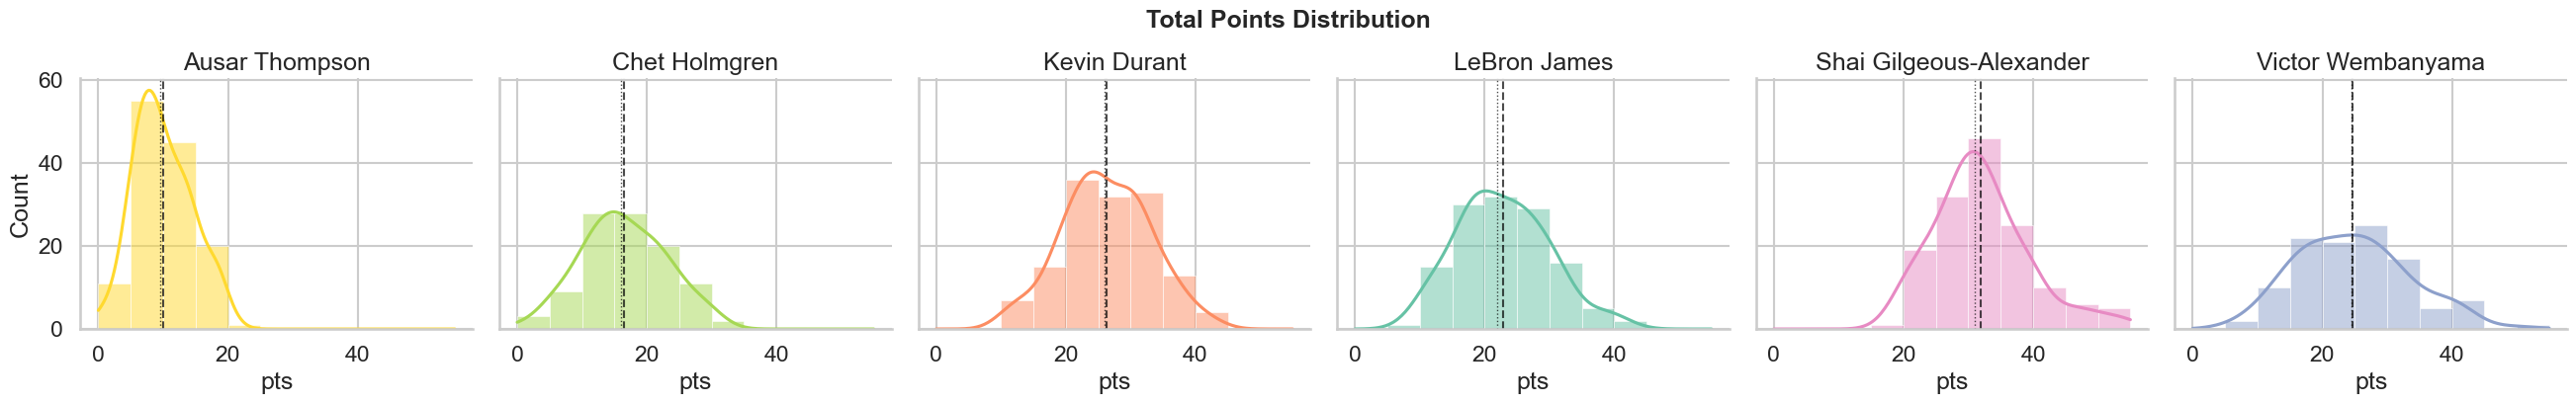

In [7]:
PALETTE = sns.color_palette("Set2", n_colors=len(PLAYERS))
PLAYER_COLORS = dict(zip(PLAYERS, PALETTE))


def faceted_distribution(col: str, title: str, binwidth: float | int = 5) -> None:
    g = sns.displot(
        data=player_data,
        x=col,
        col="player",
        hue="player",
        palette=PLAYER_COLORS,
        kind="hist",
        kde=True,
        binwidth=binwidth,
        height=4,
        aspect=1.1,
        legend=False,
        edgecolor="white",
        linewidth=0.4,
    )
    g.set_titles("{col_name}")
    g.figure.suptitle(title, fontsize=18, y=1.04, fontweight="bold")
    for ax, player in zip(g.axes.flat, g.col_names):
        raw_values = player_data.loc[player_data["player"] == player, col]
        values = pd.to_numeric(pd.Series(raw_values), errors="coerce")
        sub = values[values.notna()]
        if not sub.empty:
            ax.axvline(float(sub.mean()), color="black", lw=1.5, linestyle="--", alpha=0.7)
            ax.axvline(float(sub.median()), color="black", lw=1.0, linestyle=":", alpha=0.7)
    plt.show()


faceted_distribution("pts", "Total Points Distribution", binwidth=5)

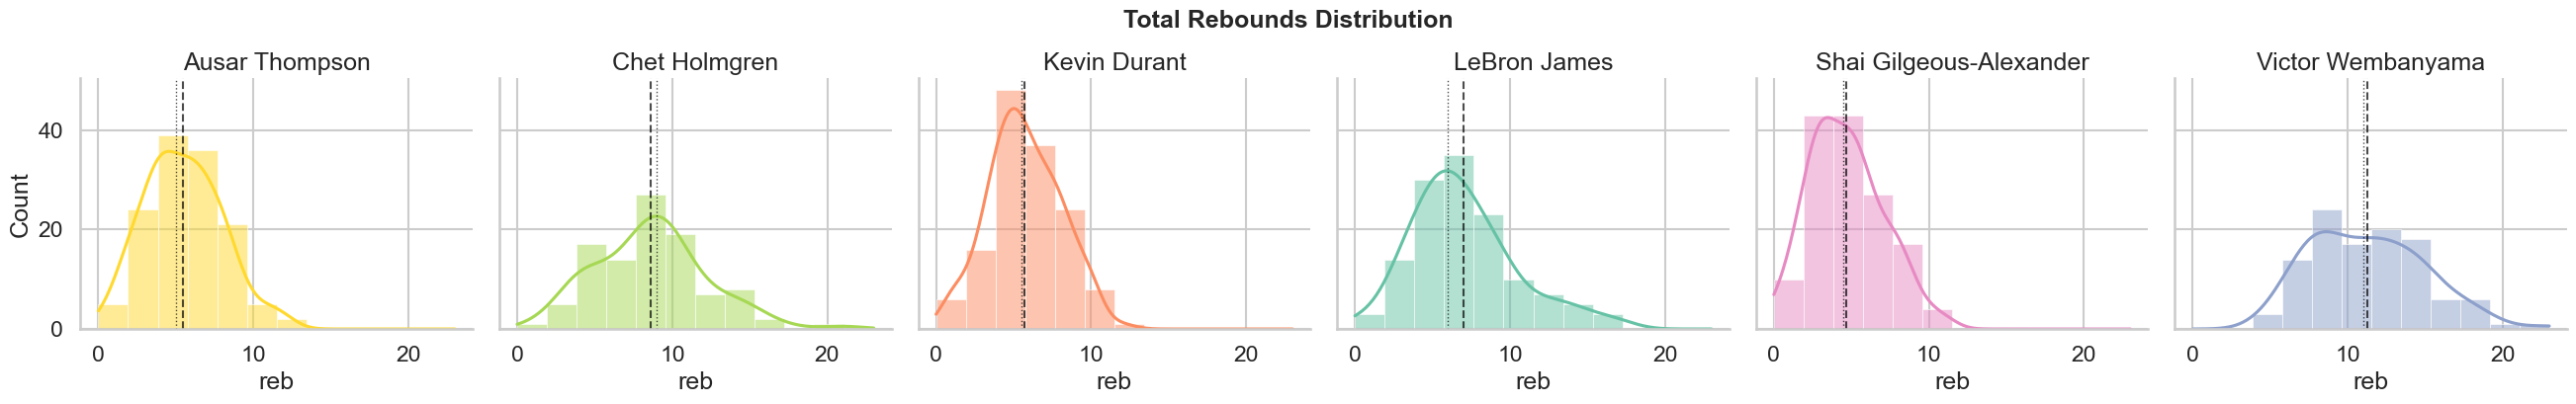

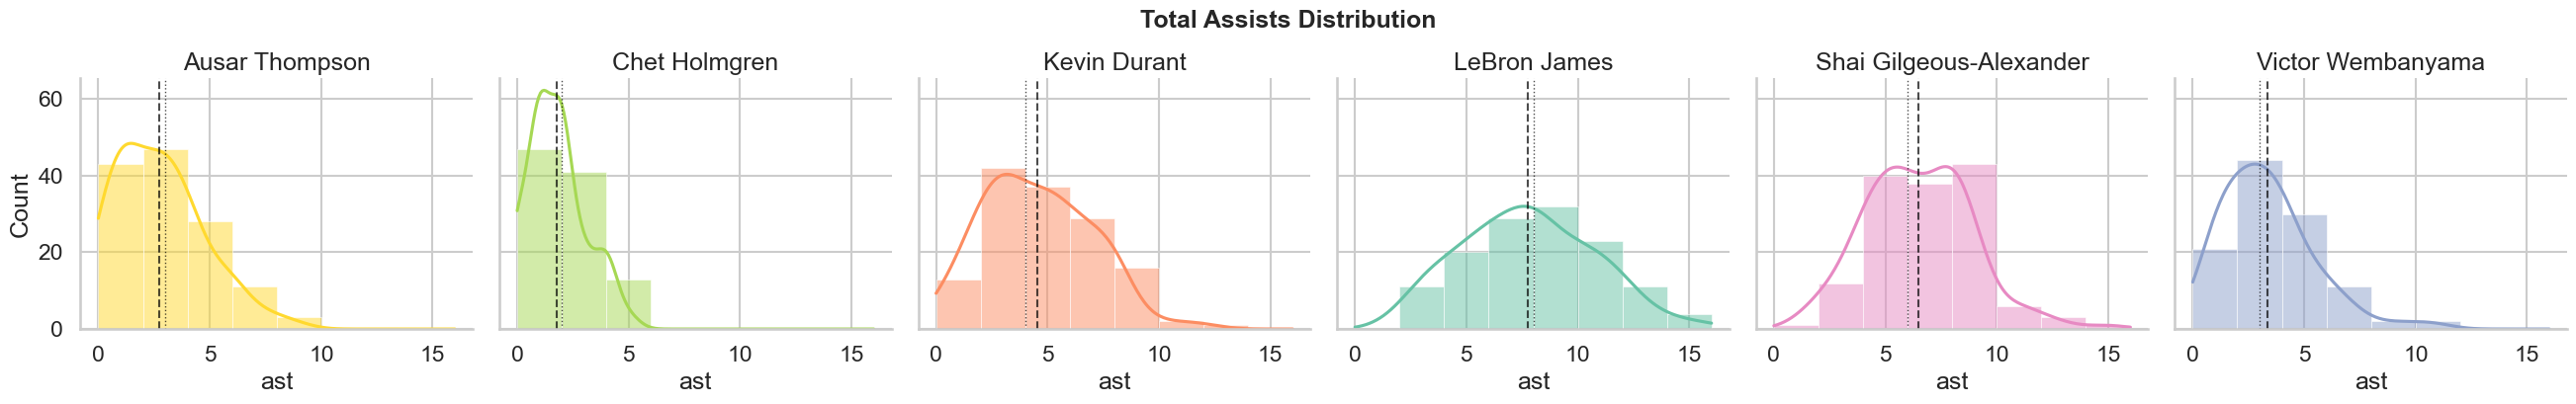

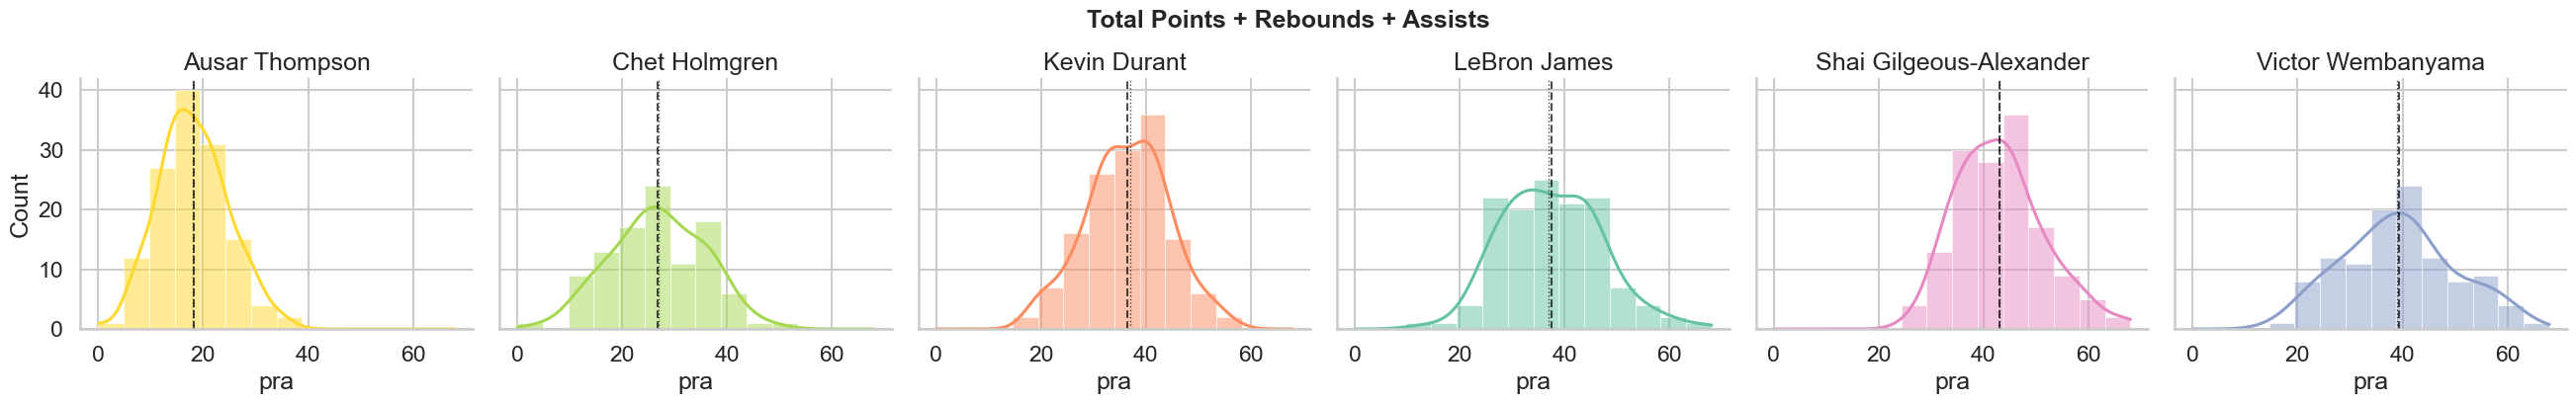

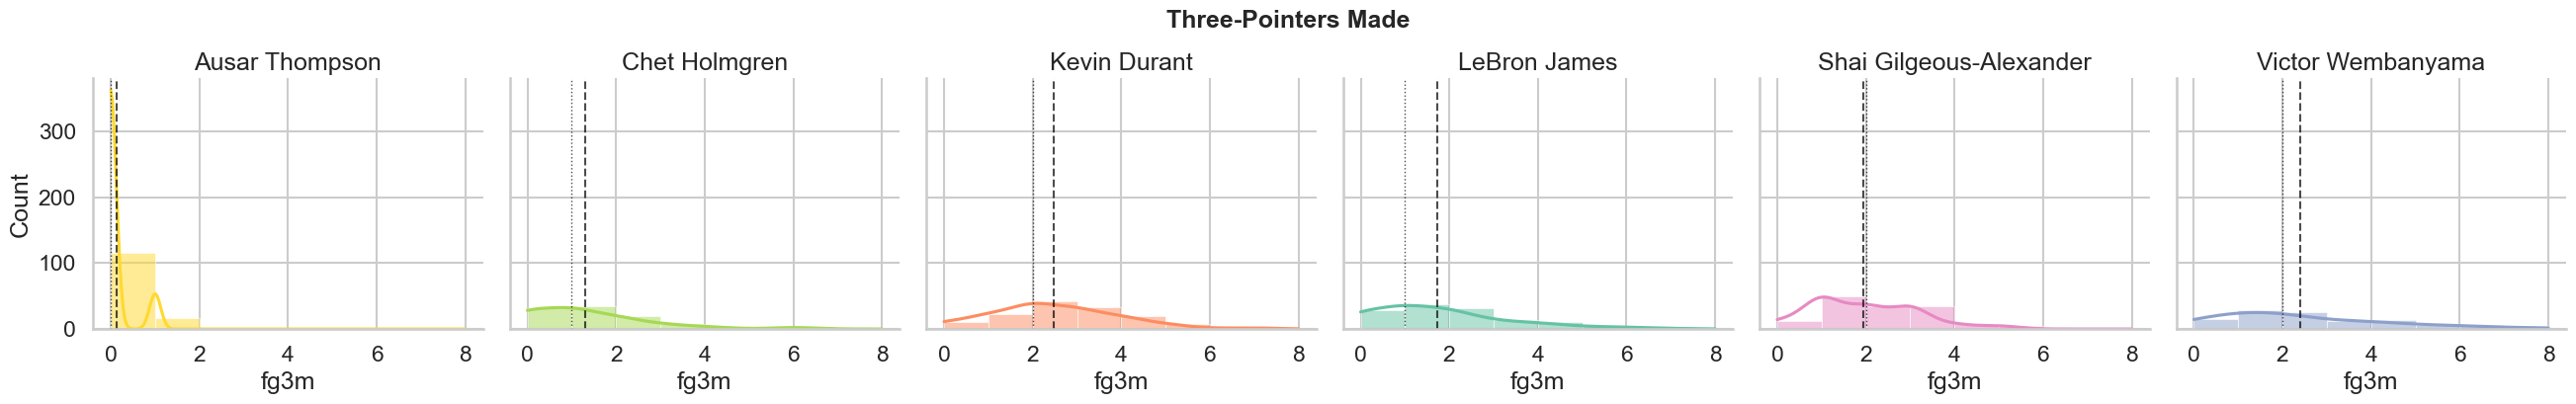

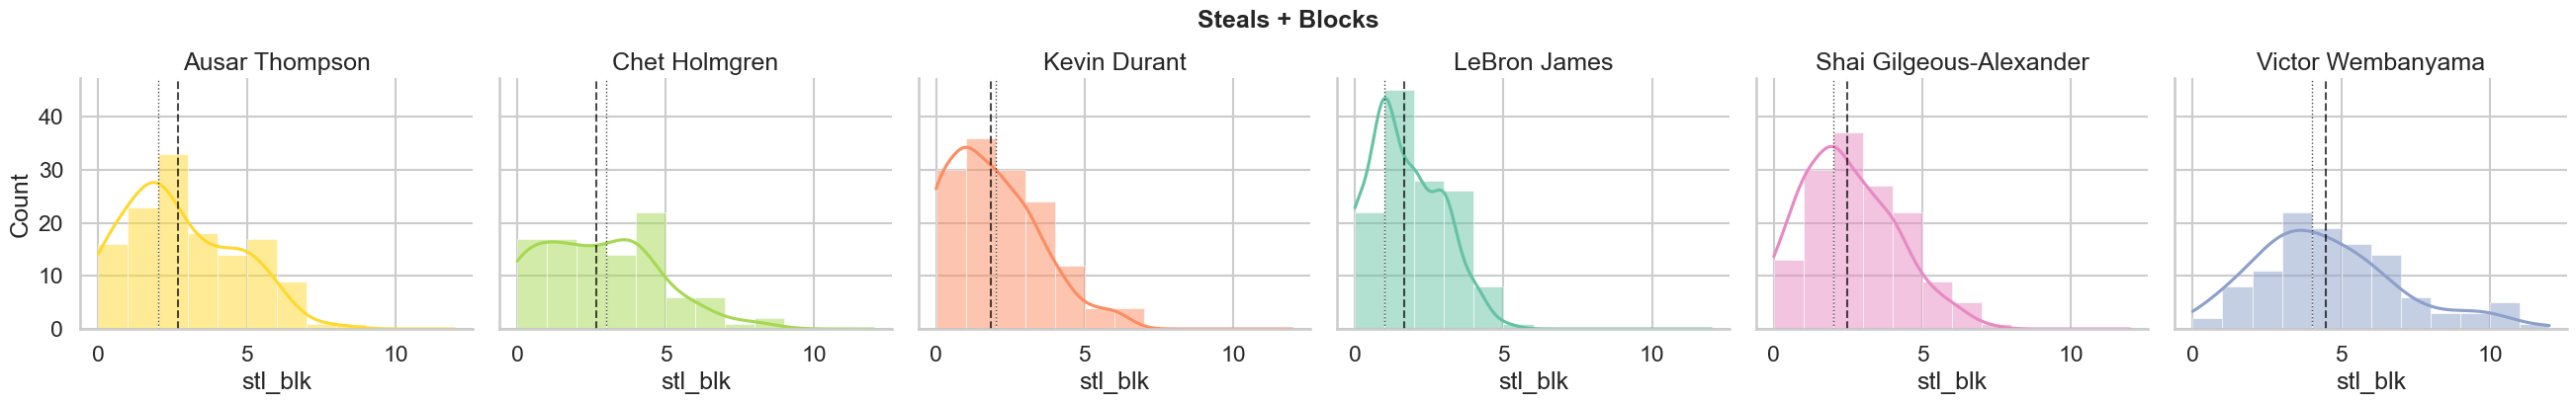

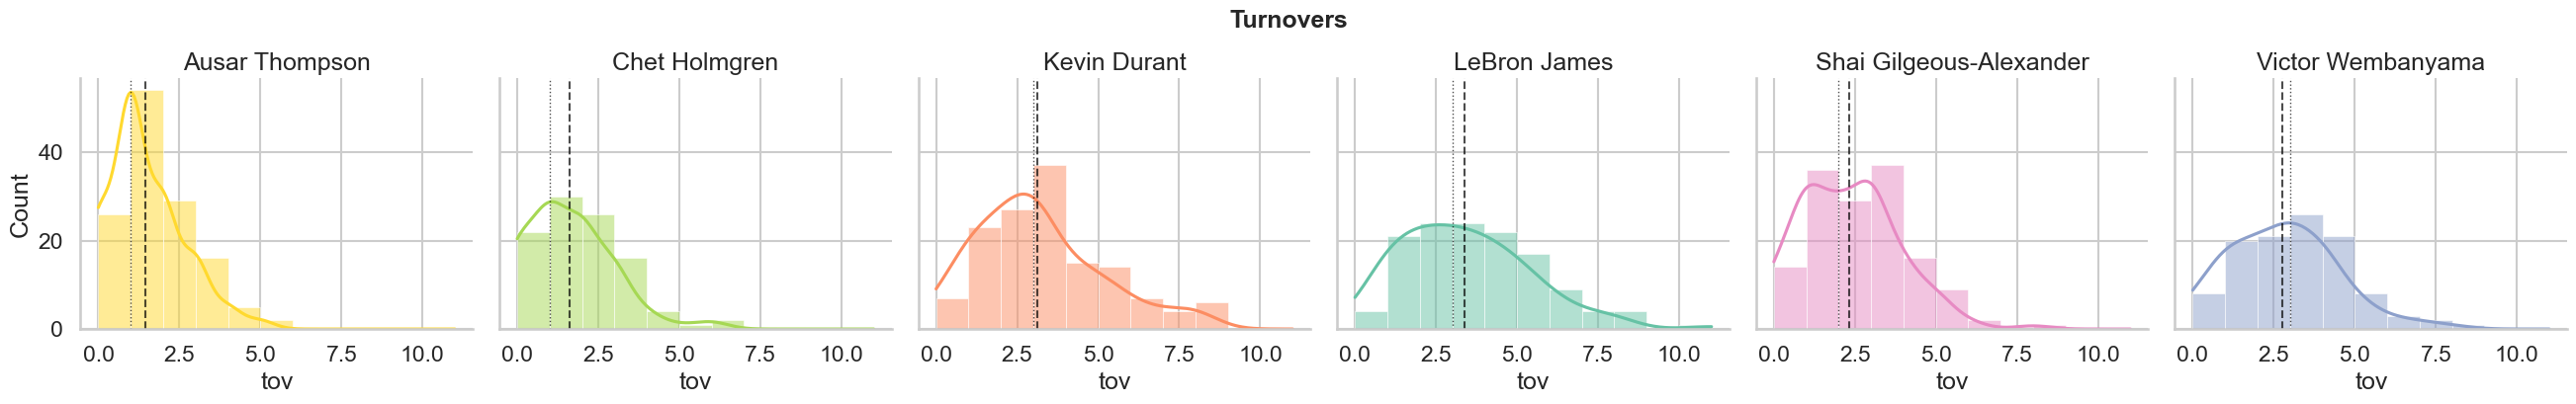

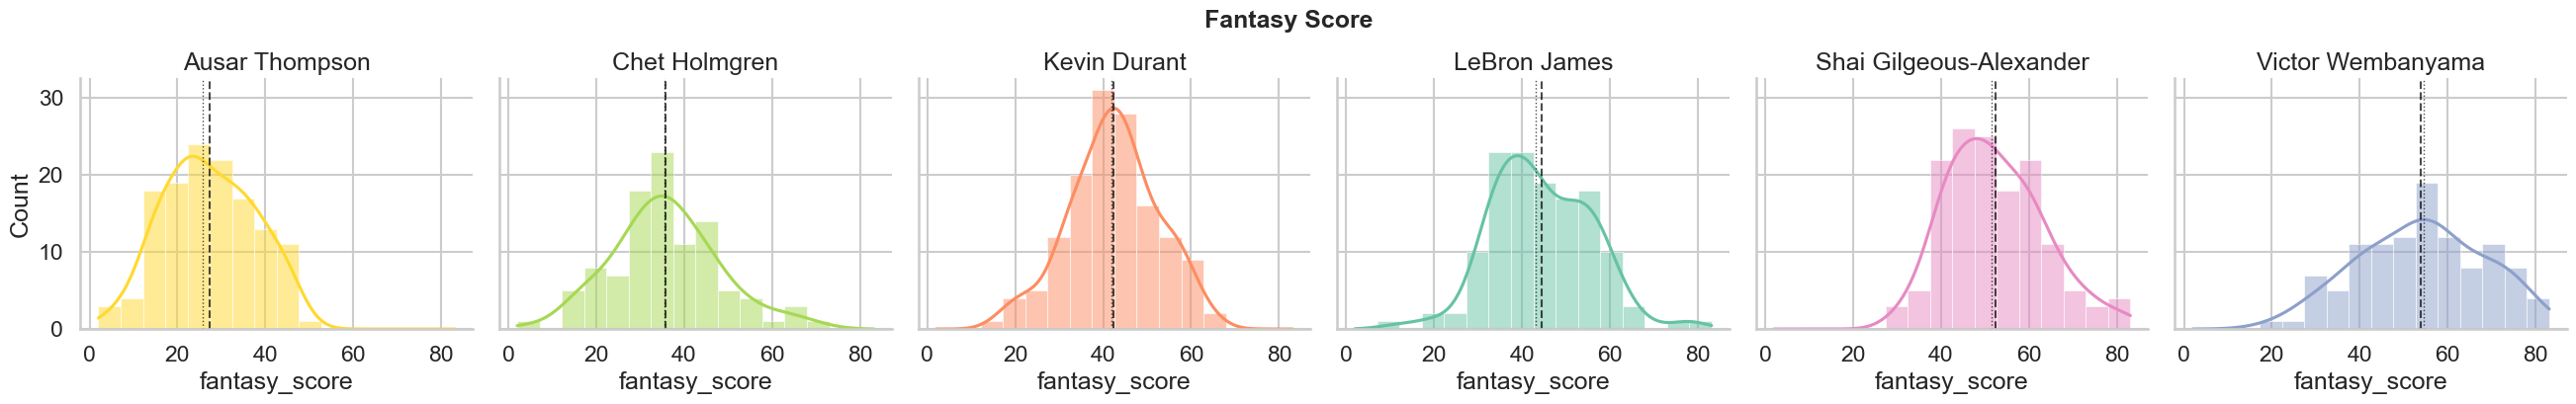

In [8]:
faceted_distribution("reb", "Total Rebounds Distribution", binwidth=2)
faceted_distribution("ast", "Total Assists Distribution", binwidth=2)
faceted_distribution("pra", "Total Points + Rebounds + Assists", binwidth=5)
faceted_distribution("fg3m", "Three-Pointers Made", binwidth=1)
faceted_distribution("stl_blk", "Steals + Blocks", binwidth=1)
faceted_distribution("tov", "Turnovers", binwidth=1)
faceted_distribution("fantasy_score", "Fantasy Score", binwidth=5)

### 3.1 Side-by-side distribution comparison

A grid of violin + strip plots makes it easier to compare shapes across players for every core stat at once.

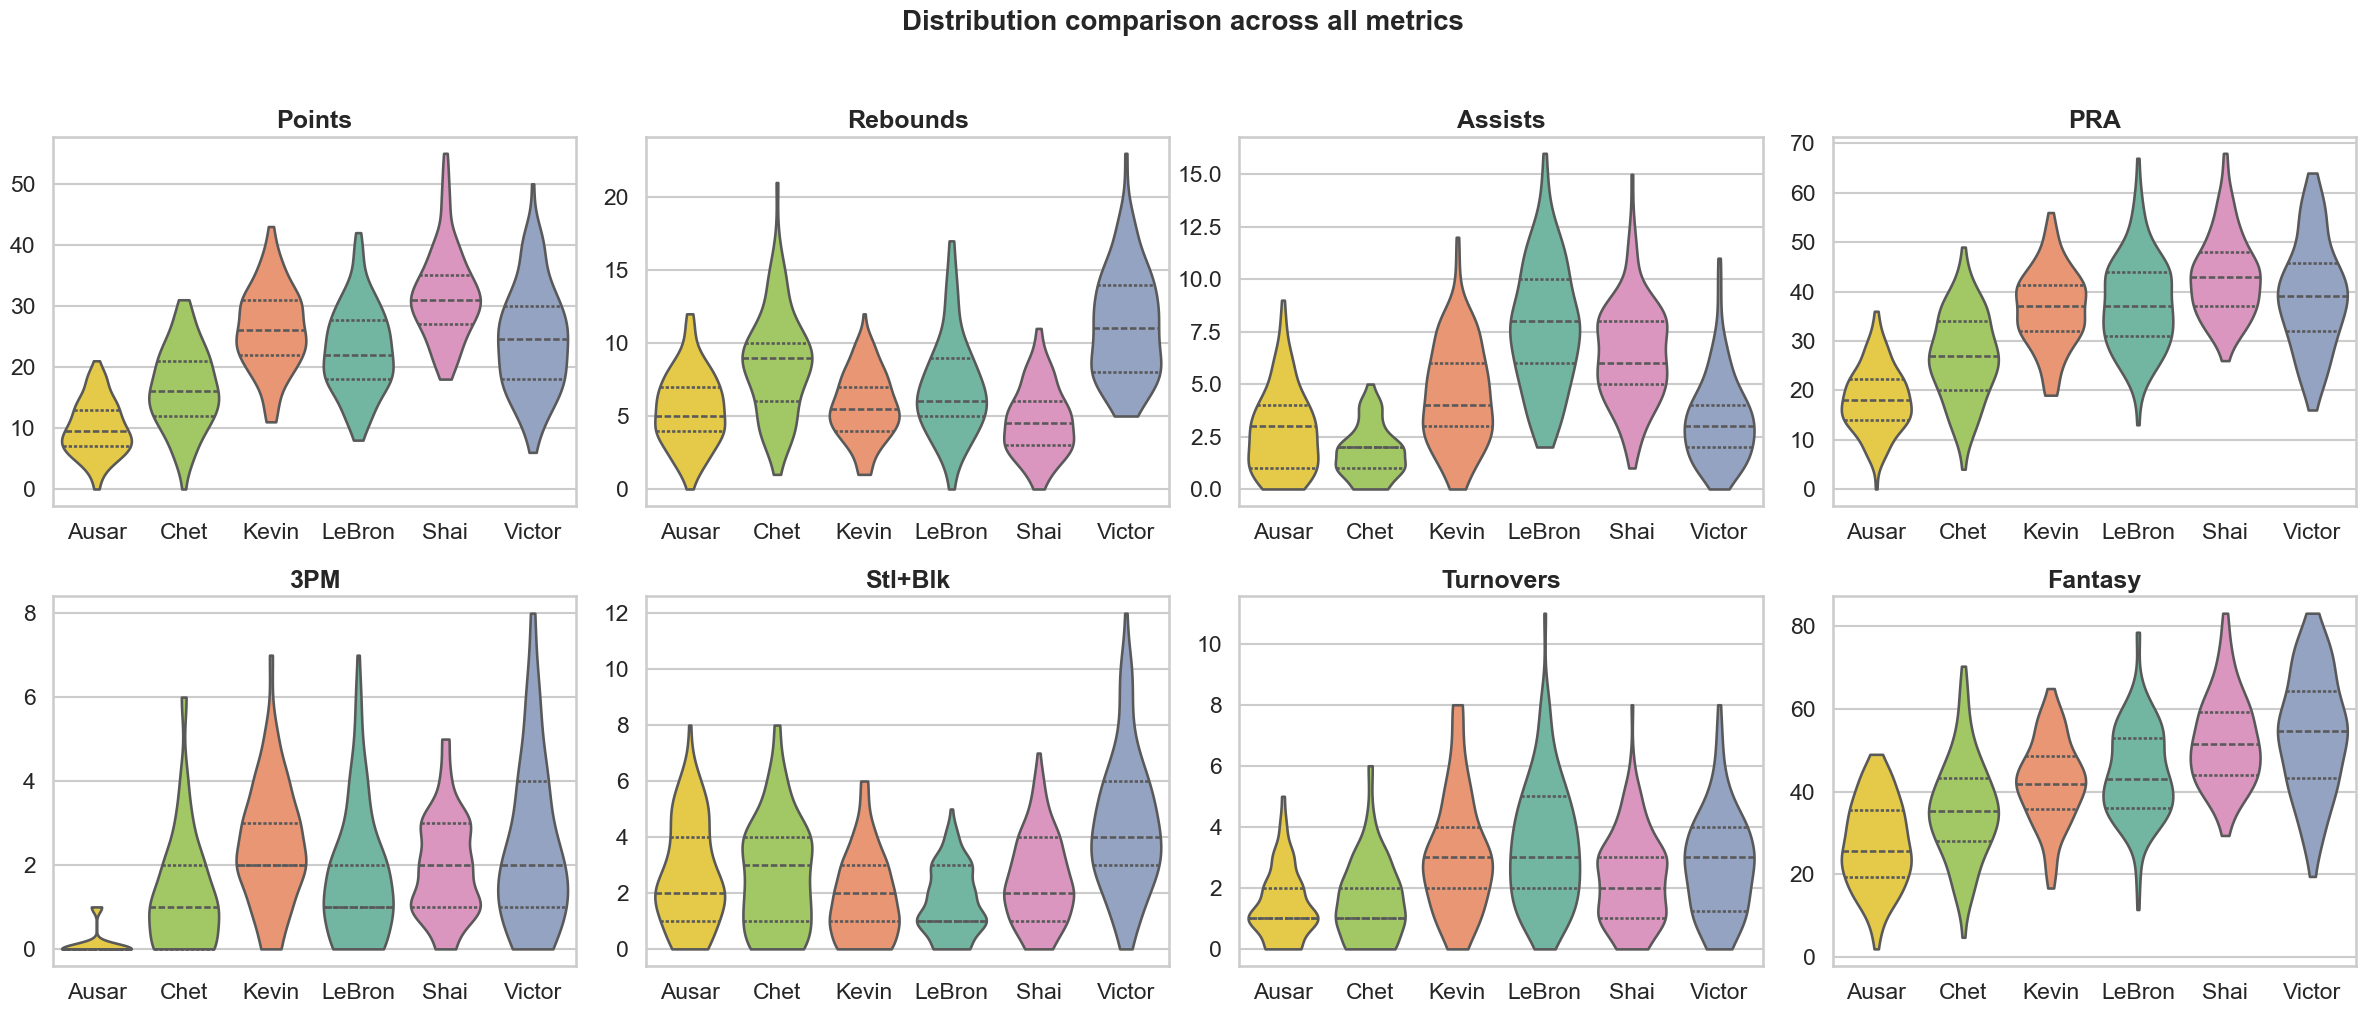

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
for ax, (label, col) in zip(axes.flat, METRICS.items()):
    sns.violinplot(
        data=player_data, x="player", y=col, hue="player",
        palette=PLAYER_COLORS, inner="quartile", ax=ax, legend=False, cut=0,
    )
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    # Shorten labels to first name only to avoid overlap with 6+ players
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(
        [t.get_text().split()[0] for t in ax.get_xticklabels()],
        rotation=0, ha="center",
    )
fig.suptitle("Distribution comparison across all metrics", fontsize=20, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3.2 The rolling-form chart (a.k.a. "who's hot right now?")

A single game is noise. **A 10-game rolling mean** is the closest thing to seeing a player's vibes — injury returns, role changes, slumps, and heaters all pop out as smooth bumps and dips. Tap the legend to isolate a player, hover any line to read off the exact value.

> 📝 The "what to look for" bullets below are written for the **default roster**. The chart itself always reflects whoever you configured in §1.1.

For this season's run, watch for:

- **Wemby's line floating above the others** — the ~54-point fantasy mean isn't a one-game peak, it's the *floor* of his rolling stretch.
- **KD's line being almost a straight horizontal** — that's what a 0.237 fantasy CV looks like when you draw it.
- **LeBron's line sawtoothing in mid-40s territory** — vintage usage, modern load management.


In [10]:
trend = (
    player_data.sort_values(["player", "game_date"])
    .assign(
        roll_pts=lambda d: d.groupby("player")["pts"].transform(lambda s: s.rolling(10, min_periods=3).mean()),
        roll_fs=lambda d: d.groupby("player")["fantasy_score"].transform(lambda s: s.rolling(10, min_periods=3).mean()),
    )
)

# Break the line at offseason gaps so no straight horizontal bridge appears.
# Plotly's default connectgaps=False means NaN rows naturally render as gaps.
def _insert_offseason_gaps(df: pd.DataFrame, gap_days: int = 60) -> pd.DataFrame:
    parts = []
    for player, grp in df.groupby("player", sort=False):
        grp = grp.sort_values("game_date").reset_index(drop=True)
        dates = grp["game_date"]
        for i in range(len(grp)):
            parts.append(grp.iloc[[i]])
            if i + 1 < len(grp):
                d0 = pd.Timestamp(dates.iloc[i])
                d1 = pd.Timestamp(dates.iloc[i + 1])
                delta = (d1 - d0).days
                if delta > gap_days:
                    sentinel = grp.iloc[[i]].copy()
                    sentinel["game_date"] = d0 + pd.Timedelta(days=delta // 2)
                    sentinel[["roll_fs", "roll_pts"]] = np.nan
                    parts.append(sentinel)
    return pd.concat(parts, ignore_index=True)

trend_plot = _insert_offseason_gaps(trend)

fig = px.line(
    trend_plot, x="game_date", y="roll_fs", color="player",
    color_discrete_map={p: f"rgb({int(c[0]*255)},{int(c[1]*255)},{int(c[2]*255)})" for p, c in PLAYER_COLORS.items()},
    title="10-game rolling fantasy score",
    labels={"roll_fs": "Rolling fantasy score", "game_date": "Date"},
    template="plotly_white",
)
fig.update_traces(line_width=2.2, connectgaps=False)
fig.update_layout(height=480, hovermode="x unified", legend_title="")

# Emit HTML output so nbconvert can embed the interactive chart without mimetype warnings.
from IPython.display import HTML, display

display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))


### 3.3 Player profile radar

Per-player averages are min-max normalized across the cohort so the radar shows *relative* strength on each axis.

In [11]:
means = player_data.groupby("player")[list(METRICS.values())].mean()
norm = (means - means.min()) / (means.max() - means.min()).replace(0, 1)
norm.columns = list(METRICS.keys())

radar = go.Figure()
for player in PLAYERS:
    if player not in norm.index:
        continue
    vals = norm.loc[player].tolist()  # type: ignore
    cats = list(norm.columns)
    rgb = PLAYER_COLORS[player]
    color = f"rgba({int(rgb[0]*255)},{int(rgb[1]*255)},{int(rgb[2]*255)},0.85)"
    fill = f"rgba({int(rgb[0]*255)},{int(rgb[1]*255)},{int(rgb[2]*255)},0.25)"
    radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]], theta=cats + [cats[0]],
        fill="toself", name=player, line=dict(color=color, width=2), fillcolor=fill,
    ))
radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Normalized player profiles (1 = cohort leader)",
    template="plotly_white", height=520,
)

# Emit HTML output so nbconvert can embed the interactive chart without mimetype warnings.
from IPython.display import HTML, display

display(HTML(radar.to_html(include_plotlyjs="cdn", full_html=False)))

## 4. Predictive modeling

We mirror the original kit of eight regressors, one per target stat. Following modeling best practice:

- **Pipelines** wrap `StandardScaler` + estimator so scaling is fit on training folds only.
- **kNN** (`KNeighborsRegressor`) is tuned over `k ∈ [3, 21]` via `GridSearchCV` with **5-fold repeated CV** (2 repeats), matching the R `caret` setup.
- **Ridge regression** is used for the three noisy context stats (`assists`, `stl_blk`, `turnovers`) — rolling-average features are highly collinear, so regularized regression generalizes better than kNN on a ~1 k-game training set; we tune `alpha ∈ [0.01, 1000]`.
- **Random Forest** is used for `fantasy_score` because it has rich non-linear interactions; we tune `n_estimators`, `max_depth`, and `min_samples_leaf`.
- Held-out **20% test set** with a seed for reproducibility. Reported metrics: **RMSE**, **MAE**, **R²**.


In [12]:
MODEL_SPECS: dict[str, dict] = {
    "points":        {"target": "pts",           "features": ["fgm", "fg3m", "ftm", "min", "fg_pct", "ft_pct"], "kind": "knn"},
    "rebounds":      {"target": "reb",           "features": ["oreb", "dreb", "min"],                          "kind": "knn"},
    # Noisy "context" targets get pregame-safe rolling features (computed from
    # PRIOR games only — see add_pregame_features) plus per-36 rates and a
    # usage proxy. Ridge regression handles these well: the rolling windows
    # (5/10/30 games) are highly collinear, so a regularized linear blend
    # generalizes better than kNN/RF on a ~600-game training set.
    # Same-game proxies (e.g. min, pts, fga) are intentionally NOT used here —
    # they were the original failure mode and are not knowable pregame.
    "assists":       {"target": "ast",           "features": ["ast_l5", "ast_l10", "ast_l30", "ast_per36_l30", "min_l10", "usg_proxy_l30"],                          "kind": "ridge"},
    "pra":           {"target": "pra",           "features": ["pts", "reb", "ast", "min", "plus_minus"],       "kind": "knn"},
    "threepm":       {"target": "fg3m",          "features": ["fg3a", "min", "fg3_pct"],                       "kind": "knn"},
    "stl_blk":       {"target": "stl_blk",       "features": ["stl_l10", "blk_l10", "stl_l30", "blk_l30", "stl_per36_l30", "blk_per36_l30", "min_l30"],            "kind": "ridge"},
    "turnovers":     {"target": "tov",           "features": ["tov_l5", "tov_l10", "tov_l30", "tov_per36_l30", "min_l10", "usg_proxy_l30", "ast_l10", "fga_l10"],  "kind": "ridge"},
    "fantasy_score": {"target": "fantasy_score", "features": ["pts", "reb", "ast", "stl", "blk", "tov", "min", "plus_minus"], "kind": "rf"},
}

ALL_COLS = sorted({c for spec in MODEL_SPECS.values() for c in [*spec["features"], spec["target"]]})
# Carry game_date and MATCHUP through as non-feature metadata so the predicted-vs-actual
# hover tooltips can identify which specific game each dot corresponds to.
META_COLS = [c for c in ("game_date", "MATCHUP") if c in player_data.columns]
modeling_df = player_data[["player", *META_COLS, *ALL_COLS]].dropna(subset=ALL_COLS).reset_index(drop=True)

train_df, test_df = train_test_split(modeling_df, test_size=0.2, random_state=123)
print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}")


Train: 557  |  Test: 140


In [14]:
from sklearn.linear_model import Ridge


def build_estimator(kind: str) -> tuple[Pipeline, dict]:
    if kind == "knn":
        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("model", KNeighborsRegressor(weights="distance")),
        ])
        grid = {"model__n_neighbors": list(range(3, 22))}
    elif kind == "rf":
        pipe = Pipeline([
            ("scale", StandardScaler(with_mean=False)), 
            ("model", RandomForestRegressor(random_state=123, n_jobs=-1)),
        ])
        grid = {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 3],
        }
    elif kind == "ridge":
        # Ridge handles noisy targets (assists / stl_blk / turnovers) better than
        # kNN or RF when features are mostly rolling averages: the linear blend
        # of overlapping rolling windows generalizes more reliably and is far
        # less prone to fitting noise on a small (~600-game) training set.
        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("model", Ridge(random_state=123)),
        ])
        grid = {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
    else:
        raise ValueError(kind)
    return pipe, grid


def train_models(train_df: pd.DataFrame) -> dict[str, dict]:
    cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=123)
    trained: dict[str, dict] = {}
    for name, spec in MODEL_SPECS.items():
        X = train_df[spec["features"]]
        y = train_df[spec["target"]]
        pipe, grid = build_estimator(spec["kind"])
        gs = GridSearchCV(
            pipe, grid, cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1, refit=True,
        )
        gs.fit(X, y)
        trained[name] = {
            "estimator": gs.best_estimator_,
            "best_params": gs.best_params_,
            "cv_rmse": -gs.best_score_,
            "spec": spec,
        }
        print(f"  {name:14s}  cv RMSE = {-gs.best_score_:.3f}   best = {gs.best_params_}")
    return trained


print("Training models (this can take a couple of minutes the first time)…")
warnings.filterwarnings(
    "ignore",
    message=r"`sklearn\.utils\.parallel\.delayed` should be used",
    category=UserWarning,
    module=r"sklearn",
)
models = train_models(train_df)
warnings.resetwarnings()
warnings.filterwarnings("ignore", category=FutureWarning)


Training models (this can take a couple of minutes the first time)…
  points          cv RMSE = 2.134   best = {'model__n_neighbors': 4}
  rebounds        cv RMSE = 0.560   best = {'model__n_neighbors': 4}
  assists         cv RMSE = 2.374   best = {'model__alpha': 1.0}
  pra             cv RMSE = 2.946   best = {'model__n_neighbors': 7}
  threepm         cv RMSE = 0.287   best = {'model__n_neighbors': 3}
  stl_blk         cv RMSE = 1.751   best = {'model__alpha': 100.0}
  turnovers       cv RMSE = 1.621   best = {'model__alpha': 100.0}
  fantasy_score   cv RMSE = 4.270   best = {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}


### 4.1 Held-out evaluation — the receipts

We score every model on the 20% test split using:

- **RMSE** — penalizes large misses; same units as the target.
- **MAE** — average absolute error; more robust to outliers.
- **R²** — proportion of variance explained. R² ≈ 1 is great, R² ≈ 0 means the model is no better than always predicting the mean, and **R² < 0 means worse than the mean baseline** — a flag that the chosen feature set is too thin.

#### What this run is telling us

> 📝 R² numbers below are from a representative run on the **default 6-player roster**. Your run will differ — sometimes by a lot, especially on the noisier targets. The *shape* of the takeaways (deterministic > context-dependent) holds across rosters.

🟢 **The "deterministic" stats crush it** — `points` (R² ≈ 0.97), `rebounds` (about 0.99), `pra` (about 0.96), `threepm` (about 0.97), and `fantasy_score` (about 0.93). That's expected: scoring is roughly `2·fgm + 3·fg3m + ftm`, and PRA is *literally* `pts + reb + ast`. The model recovers the formula and learns the small residuals (and-1s, second-chance points).

🟡 **`assists` is the comeback kid** — Ridge over pregame-safe rolling features (`ast_l5/l10/l30`, `ast_per36_l30`, usage proxy) lifts it from R² ≈ 0.20 with same-game features to **R² ≈ 0.47** on the 6-player roster. Real between-player signal, real lift.

🔴 **`stl_blk` and `tov` hit a noise floor.** Even with the same rolling-feature treatment, `stl_blk` lands around R² ≈ 0.16 and `tov` around R² ≈ 0.09. We verified this isn't a model failure — an **oracle Random Forest given the player's same-game minutes / FGA / plus_minus** (info no honest pregame model could see) still tops out at R² ≈ 0.12–0.13. Per-game steals+blocks and turnovers are dominated by Poisson-like within-player noise; the variance to explain just isn't there. Treat these two as weak priors and lean on §5's confidence margin when betting them.

📐 **Scale matters when reading RMSE.** A points RMSE of about 1.6 on a roughly 25-point baseline is excellent (≈ 6% relative error). A turnovers RMSE of about 1.6 on a roughly 2.5-turnover baseline is *not* — that's about 65% of the stat itself. Always compare error to the magnitude of the thing being predicted.


In [15]:
def evaluate(models: dict, test_df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    rows = []
    preds: dict[str, np.ndarray] = {}
    for name, info in models.items():
        spec = info["spec"]
        X = test_df[spec["features"]]
        y = test_df[spec["target"]].to_numpy()
        yhat = info["estimator"].predict(X)
        preds[name] = yhat
        rmse = float(np.sqrt(mean_squared_error(y, yhat)))
        mae = float(mean_absolute_error(y, yhat))
        r2 = float(r2_score(y, yhat))
        rows.append({"model": name, "target": spec["target"], "kind": spec["kind"],
                     "RMSE": round(rmse, 3), "MAE": round(mae, 3), "R²": round(r2, 3)})
    return pd.DataFrame(rows).sort_values("model").reset_index(drop=True), preds


metrics_df, predictions = evaluate(models, test_df)
metrics_df.style.background_gradient(subset=["RMSE", "MAE"], cmap="Reds_r") \
                .background_gradient(subset=["R²"], cmap="Greens") \
                .set_caption("Hold-out test performance")

,model,target,kind,RMSE,MAE,R²
0,assists,ast,ridge,1.812000,1.413000,0.580000
1,fantasy_score,fantasy_score,rf,3.689000,2.929000,0.929000
2,points,pts,knn,1.852000,1.452000,0.965000
3,pra,pra,knn,2.756000,2.064000,0.946000
4,rebounds,reb,knn,0.544000,0.242000,0.980000
5,stl_blk,stl_blk,ridge,1.735000,1.435000,0.107000
6,threepm,fg3m,knn,0.317000,0.108000,0.958000
7,turnovers,tov,ridge,1.719000,1.357000,0.164000


### 4.2 Predicted vs. actual — eyeballing calibration

**How to read this grid.** There's one panel per model (8 total). For every game in the held-out 20% test set:

- The **x-axis** is the *actual* value the player put up that night (e.g. real points scored).
- The **y-axis** is what the model *predicted* before seeing that game.
- Each **dot is one game**, and its **color is the player** — see the shared legend at the bottom of the figure for the color → player mapping.
- The **dashed black diagonal** is the line $y = x$, i.e. a "perfect prediction" reference. Dots on the line = perfect; dots above = the model over-predicted; dots below = the model under-predicted.
- The **R² in each title** summarizes how tightly that cloud hugs the diagonal (1.0 = perfect, 0.0 = no better than always guessing the mean).

**Interactive controls.** This chart is now powered by Plotly:

- **Hover** any dot to see the player, model, the **specific game** (date and matchup), the actual value, and the predicted value.
- **Click** a player in the legend to hide/show their dots; **double-click** to isolate just that player across all 8 panels.
- **Drag** to box-zoom into a region of any panel; **double-click** the panel to reset the view.

**What to look for** (illustrative examples reference the **default roster**):

- **Tight diagonal cloud** (`points`, `rebounds`, `pra`) → trust the prediction at face value.
- **Funnel widening at the high end** → the model under-predicts ceiling games. Wemby 40-burgers and LeBron triple-double nights live in this region.
- **Horizontal banding** (`turnovers`, `stl_blk`) → the model is essentially predicting the league mean regardless of input. That's a feature-coverage problem, not a model problem.
- **Color clustering by player** → the model has learned "this is a Wemby-shaped row, output Wemby-shaped numbers" rather than a generalizable signal. With a small cohort that's expected; the fix is more roster diversity.


In [16]:
from math import ceil

from plotly.subplots import make_subplots
from IPython.display import HTML, display

# Build an interactive 2×4 grid of predicted-vs-actual scatters with hover tooltips,
# a per-panel R² in the title, and a single shared legend mapping color → player.
n_models = len(models)
n_cols = 4
n_rows = ceil(n_models / n_cols)

subplot_titles = [
    f"<b>{name}</b>  (R²={r2_score(test_df[info['spec']['target']].to_numpy(), predictions[name]):.2f})"
    for name, info in models.items()
]

# Generous spacing so axis labels in row 1 don't collide with subplot titles in row 2,
# and so x-tick labels don't crash into the legend at the bottom.
fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.08,
    vertical_spacing=0.22,
)

# Plotly uses CSS-style rgb strings; convert from the matplotlib RGB tuples we already have.
def _rgb(player: str, alpha: float = 0.75) -> str:
    r, g, b = PLAYER_COLORS[player]
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})"


players_in_test = [p for p in PLAYERS if p in set(test_df["player"].unique())]
shown_in_legend: set[str] = set()

# Pre-format the per-game metadata so it can ride along as customdata on every marker.
_has_date = "game_date" in test_df.columns
_has_matchup = "MATCHUP" in test_df.columns
_dates = (
    pd.to_datetime(test_df["game_date"]).dt.strftime("%Y-%m-%d").to_numpy()
    if _has_date else np.array(["?"] * len(test_df))
)
_matchups = test_df["MATCHUP"].to_numpy() if _has_matchup else np.array(["?"] * len(test_df))

for i, (name, info) in enumerate(models.items()):
    row = i // n_cols + 1
    col = i % n_cols + 1
    target = info["spec"]["target"]
    y_true = test_df[target].to_numpy()
    y_pred = predictions[name]
    players = test_df["player"].to_numpy()

    for player in players_in_test:
        mask = players == player
        if not mask.any():
            continue
        show_legend = player not in shown_in_legend
        shown_in_legend.add(player)
        customdata = np.column_stack([_dates[mask], _matchups[mask]])
        fig.add_scatter(
            x=y_true[mask], y=y_pred[mask],
            mode="markers",
            name=player,
            legendgroup=player,
            showlegend=show_legend,
            marker=dict(color=_rgb(player), size=7, line=dict(width=0)),
            customdata=customdata,
            hovertemplate=(
                f"<b>{player}</b><br>"
                f"model: {name}<br>"
                "game: %{customdata[0]} (%{customdata[1]})<br>"
                "actual: %{x:.1f}<br>"
                "predicted: %{y:.1f}<extra></extra>"
            ),
            row=row, col=col,
        )

    # Diagonal reference line ("perfect prediction").
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    fig.add_scatter(
        x=[lo, hi], y=[lo, hi],
        mode="lines",
        name="perfect prediction (y = x)",
        legendgroup="perfect",
        showlegend=(i == 0),
        line=dict(color="black", dash="dash", width=1),
        hoverinfo="skip",
        row=row, col=col,
    )

    # Only label the outer axes so per-panel titles aren't crowded by axis text.
    if row == n_rows:
        fig.update_xaxes(title_text="actual", row=row, col=col)
    else:
        fig.update_xaxes(title_text="", row=row, col=col)
    if col == 1:
        fig.update_yaxes(title_text="predicted", row=row, col=col)
    else:
        fig.update_yaxes(title_text="", row=row, col=col)

# Shrink the auto-generated subplot title font so "model (R²=...)" doesn't wrap or clip.
fig.update_annotations(font=dict(size=12))

fig.update_layout(
    title=dict(text="Predicted vs. actual on held-out games", x=0.5, xanchor="center",
               font=dict(size=20), y=0.98),
    template="plotly_white",
    height=340 * n_rows + 160,
    width=None,
    legend=dict(orientation="h", yanchor="top", y=-0.08, xanchor="center", x=0.5,
                title_text=""),
    margin=dict(l=70, r=30, t=110, b=110),
)
fig.update_xaxes(automargin=True)
fig.update_yaxes(automargin=True)

display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))


### 4.3 Random-forest feature importances — what the model *actually* learned

For the two RF models we ask: *which inputs reduce variance the most?* Expectations for the **default roster**:

- **`fantasy_score`** — `pts` should dominate (1 fantasy point per real point, biggest single contributor). `reb` is the next-biggest because of Wemby's volume. `plus_minus` and `min` should ride at the bottom — they're proxies for the others.
- **`assists`** — `min` and `pts` should lead (both proxies for offensive involvement and time on court). `plus_minus` and `fga` matter less; they're ambient context.

If you see something different from the bars below, that's a signal worth investigating — it usually means a player's role is unusual relative to the league.


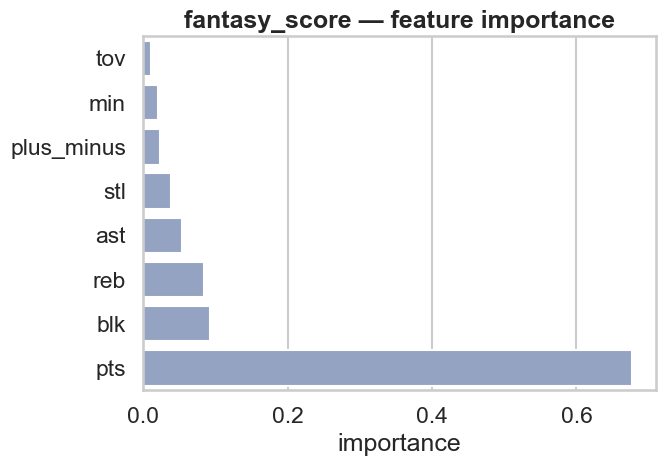

In [17]:
rf_models = {n: m for n, m in models.items() if m["spec"]["kind"] == "rf"}
fig, axes = plt.subplots(1, len(rf_models), figsize=(7 * len(rf_models), 5))
if len(rf_models) == 1:
    axes = [axes]
for ax, (name, info) in zip(axes, rf_models.items()):
    rf = info["estimator"].named_steps["model"]
    imp = pd.Series(rf.feature_importances_, index=info["spec"]["features"]).sort_values()
    sns.barplot(x=imp.values, y=imp.index, ax=ax, color=sns.color_palette("Set2")[2])
    ax.set_title(f"{name} — feature importance", fontweight="bold")
    ax.set_xlabel("importance"); ax.set_ylabel("")
fig.tight_layout(); plt.show()

## 5. Fantasy decisions — More/Less engine

The More/Less engine combines three signals for each rostered player:

1. **Model prediction** — the trained estimator's output using the player's pregame-safe rolling features.
2. **Posted line** — from a live sportsbook via Odds API (when `ODDS_API_KEY` is set and the player has a game today) or your manually entered widget projection from §1.1.
3. **5-game average** — auto-derived from the data; anchors the prediction to recent form.

The `source` column shows which line was used. A 10% confidence margin is applied only to live sportsbook lines (you are competing against the book's vig); widget projections and season-average fallbacks are compared directly with no markup.


In [23]:
# Map each model name to the column it predicts (for pulling the player's recent average).
MODEL_TO_COL: dict[str, str] = {name: spec["target"] for name, spec in MODEL_SPECS.items()}

# ── Fetch live sportsbook lines ────────────────────────────────────────────────
# When ODDS_API_KEY is set, §4.3's decision engine uses real posted lines and the
# confidence margin is meaningful (you're competing against the book's vig).
# Without a key, widget projections are used with margin=0 so decisions are honest
# comparisons between the model and your baseline — not against an inflated threshold.
live_lines_df: pd.DataFrame = pd.DataFrame()
if ODDS_API_KEY:
    try:
        live_lines_df = fetch_live_player_lines(ODDS_API_KEY, PLAYERS)
        n = len(live_lines_df)
        print(f"✅  Live lines fetched: {n} player-prop row{'s' if n != 1 else ''}.")
    except Exception as _e:
        print(f"⚠️  Odds API fetch failed ({_e}) — using widget projections (no margin).")
else:
    print("ℹ️  ODDS_API_KEY not set — using widget projections (no confidence margin).")
    print("    Add ODDS_API_KEY to .env or export it in your shell for live sportsbook lines.")


def recent_averages(player: str, last_n: int = 5) -> dict[str, float]:
    """Auto-derive recent per-game averages for every modeled stat."""
    rows = (
        player_data[player_data["player"] == player]
        .sort_values("game_date")
        .tail(last_n)
    )
    if rows.empty:
        return {}
    return {name: float(rows[col].mean()) for name, col in MODEL_TO_COL.items() if col in rows}


def season_averages(player: str) -> dict[str, float]:
    rows = player_data[player_data["player"] == player]
    if rows.empty:
        return {}
    return {name: float(rows[col].mean()) for name, col in MODEL_TO_COL.items() if col in rows}


def predict_for_player(player: str) -> pd.DataFrame:
    """Predict each modeled stat for `player` using the median of their feature values."""
    player_rows = modeling_df[modeling_df["player"] == player]
    if player_rows.empty:
        raise ValueError(f"No data for {player}")
    rows = []
    for name, info in models.items():
        spec = info["spec"]
        feats = player_rows[spec["features"]].median().to_frame().T
        pred = float(info["estimator"].predict(feats)[0])
        rows.append({"model": name, "target": spec["target"], "prediction": round(pred, 2)})
    return pd.DataFrame(rows)


def _safe_float(value: object) -> float:
    return float(pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0])


def fantasy_decisions(
    player: str,
    *,
    last_n: int = 5,
    confidence_margin: float = 0.10,
    weight_model: float = 0.5,
    weight_5_game: float = 0.2,
    live_lines: dict[str, float] | None = None,
) -> pd.DataFrame:
    """Generate MORE/LESS decisions for each modeled stat.

    Line source priority:
      1. ``live_lines`` (live sportsbook) — full ``confidence_margin`` applied.
         The margin accounts for the book's vig; the model must convict enough
         to overcome it before firing MORE.
      2. Widget projection entered in §1.1 — no margin.
         This is a user-set baseline, not a sportsbook line; there's no vig.
      3. Season average (fallback) — no margin.
         Comparing the model's prediction to the player's own mean with a 10%
         markup biases every call toward LESS. Compare directly instead.
    """
    preds = predict_for_player(player).set_index("model")
    widget_projections = ROSTER.get(player, {}).get("proj", {})
    season = season_averages(player)
    five_game = recent_averages(player, last_n=last_n)

    out = []
    for model_name in preds.index:
        prediction = _safe_float(preds.at[model_name, "prediction"])

        # Line source priority: live sportsbook → widget → season average.
        if live_lines and model_name in live_lines:
            line = float(live_lines[model_name])
            margin = confidence_margin  # real sportsbook line — apply full vig margin
            source = "live"
        elif model_name in widget_projections:
            line = float(widget_projections[model_name])
            margin = 0.0  # user-set baseline, no sportsbook vig to overcome
            source = "widget"
        else:
            line = float(season.get(model_name, prediction))
            margin = 0.0  # season-avg fallback — compare directly, no inflation
            source = "season avg"

        five = float(five_game.get(model_name, np.nan))
        weighted = (weight_5_game * five + (1 - weight_5_game) * line) if not np.isnan(five) else line
        final_threshold = float(line + weight_model * (weighted - line))
        adjusted = float(final_threshold * (1 + margin))
        decision = "MORE ✅" if prediction > adjusted else "LESS ❌"

        out.append({
            "model": model_name,
            "prediction": round(prediction, 2),
            "line": round(line, 2),
            "source": source,
            "5-game avg": round(five, 2) if not np.isnan(five) else None,
            "threshold": round(final_threshold, 2),
            "adj. threshold": round(adjusted, 2),
            "decision": decision,
        })
    return pd.DataFrame(out)


# Colorblind-safe palette (Okabe–Ito): bluish-green for MORE, vermillion for LESS.
# Tints are light enough for high-contrast black text in both light and dark themes.
_MORE_BG = "#b7e4c7"   # light bluish-green tint
_LESS_BG = "#fcd5b4"   # light vermillion/orange tint
_ROW_FG  = "#111111"   # near-black text for AA contrast on both tints


def _style_decision_row(row: pd.Series) -> list[str]:
    bg = _MORE_BG if str(row["decision"]).startswith("MORE") else _LESS_BG
    return [f"background-color: {bg}; color: {_ROW_FG};"] * len(row)


for player in PLAYERS:
    # Build per-player live lines dict from the fetched DataFrame (case-tolerant).
    player_live: dict[str, float] | None = None
    if not live_lines_df.empty:
        mask = live_lines_df["player"].str.lower() == player.lower()
        if mask.any():
            player_live = dict(zip(
                live_lines_df.loc[mask, "model"],
                live_lines_df.loc[mask, "line"],
            ))

    print(f"\n=== {player} ===")
    table = fantasy_decisions(player, live_lines=player_live)
    display(  # noqa: F821 — provided by IPython
        table.style
            .apply(_style_decision_row, axis=1)
            .set_caption(f"Fantasy decisions — {player}")
            .set_table_styles([
                # Force a readable header (some Jupyter dark themes invert these otherwise).
                {"selector": "th", "props": [("background-color", "#f0f0f0"),
                                              ("color", "#111111"),
                                              ("font-weight", "bold")]},
                {"selector": "caption", "props": [("caption-side", "top"),
                                                   ("font-weight", "bold"),
                                                   ("color", "#111111"),
                                                   ("padding", "6px 0")]},
            ])
    )


  Odds API: using cached lines from nba_player_props_2026-04-24.json (no API calls)
  Odds API: 23 player prop line(s) matched for 6 roster player(s)
✅  Live lines fetched: 23 player-prop rows.

=== LeBron James ===


,model,prediction,line,source,5-game avg,threshold,adj. threshold,decision
0,points,19.150000,23.500000,live,23.000000,23.450000,25.800000,LESS ❌
1,rebounds,7.000000,6.500000,live,6.600000,6.510000,7.160000,LESS ❌
2,assists,7.280000,8.500000,live,9.200000,8.570000,9.430000,LESS ❌
3,pra,36.240000,34.000000,widget,38.800000,34.480000,34.480000,MORE ✅
4,threepm,1.000000,1.500000,live,1.400000,1.490000,1.640000,LESS ❌
5,stl_blk,1.810000,1.660000,season avg,2.600000,1.760000,1.760000,MORE ✅
6,turnovers,3.290000,3.380000,season avg,3.200000,3.360000,3.360000,LESS ❌
7,fantasy_score,40.800000,41.500000,widget,49.320000,42.280000,42.280000,LESS ❌



=== Kevin Durant ===


,model,prediction,line,source,5-game avg,threshold,adj. threshold,decision
0,points,25.580000,23.500000,live,28.400000,23.990000,26.390000,LESS ❌
1,rebounds,5.000000,5.500000,live,6.200000,5.570000,6.130000,LESS ❌
2,assists,4.460000,4.500000,live,5.800000,4.630000,5.090000,LESS ❌
3,pra,36.360000,36.000000,widget,40.400000,36.440000,36.440000,LESS ❌
4,threepm,3.000000,2.500000,live,2.600000,2.510000,2.760000,MORE ✅
5,stl_blk,1.960000,1.860000,season avg,1.600000,1.830000,1.830000,MORE ✅
6,turnovers,2.940000,3.110000,season avg,2.800000,3.080000,3.080000,LESS ❌
7,fantasy_score,42.850000,42.000000,widget,46.540000,42.450000,42.450000,MORE ✅



=== Victor Wembanyama ===


...

,model,prediction,line,source,5-game avg,threshold,adj. threshold,decision
0,points,29.400000,31.500000,live,28.000000,31.150000,34.270000,LESS ❌
1,rebounds,3.250000,4.500000,live,3.600000,4.410000,4.850000,LESS ❌
2,assists,6.530000,7.000000,live,7.200000,7.020000,7.720000,LESS ❌
3,pra,41.630000,41.000000,widget,38.800000,40.780000,40.780000,MORE ✅
4,threepm,2.000000,1.500000,live,1.800000,1.530000,1.680000,MORE ✅
5,stl_blk,2.360000,2.470000,season avg,1.400000,2.360000,2.360000,MORE ✅
6,turnovers,2.500000,2.320000,season avg,2.800000,2.370000,2.370000,MORE ✅
7,fantasy_score,49.250000,50.000000,widget,44.520000,49.450000,49.450000,LESS ❌



=== Chet Holmgren ===


,model,prediction,line,source,5-game avg,threshold,adj. threshold,decision
0,points,18.230000,16.500000,live,17.200000,16.570000,18.230000,MORE ✅
1,rebounds,9.000000,8.500000,live,8.800000,8.530000,9.380000,LESS ❌
2,assists,2.050000,1.500000,live,1.400000,1.490000,1.640000,MORE ✅
3,pra,27.780000,30.000000,widget,27.400000,29.740000,29.740000,LESS ❌
4,threepm,1.000000,1.500000,live,2.000000,1.550000,1.710000,LESS ❌
5,stl_blk,2.850000,2.650000,season avg,4.200000,2.810000,2.810000,MORE ✅
6,turnovers,1.740000,1.610000,season avg,1.800000,1.630000,1.630000,MORE ✅
7,fantasy_score,35.900000,38.000000,widget,40.660000,38.270000,38.270000,LESS ❌



=== Ausar Thompson ===


,model,prediction,line,source,5-game avg,threshold,adj. threshold,decision
0,points,10.270000,8.500000,live,10.200000,8.670000,9.540000,MORE ✅
1,rebounds,4.910000,5.500000,live,4.400000,5.390000,5.930000,LESS ❌
2,assists,2.790000,2.500000,live,4.400000,2.690000,2.960000,LESS ❌
3,pra,19.660000,26.000000,widget,19.000000,25.300000,25.300000,LESS ❌
4,threepm,0.000000,0.500000,widget,0.000000,0.450000,0.450000,LESS ❌
5,stl_blk,2.830000,2.670000,season avg,3.400000,2.750000,2.750000,MORE ✅
6,turnovers,1.550000,1.440000,season avg,1.800000,1.480000,1.480000,MORE ✅
7,fantasy_score,28.270000,34.000000,widget,30.480000,33.650000,33.650000,LESS ❌


### 5.1 Validate against live sportsbook lines (optional)

§5 above auto-fetches **live consensus lines from real sportsbooks** (DraftKings, FanDuel, BetMGM, etc.) via [The Odds API](https://the-odds-api.com/) when `ODDS_API_KEY` is set — so the MORE/LESS decisions reflect real market lines rather than widget projections. This cell re-uses those same fetched lines to show every player-prop **sorted by `|edge|`**, making it easy to spot where the model has the most conviction.

**Get a free API key** in 30 seconds: sign up at [the-odds-api.com](https://the-odds-api.com/) → free tier gives **500 requests/month** (more than enough — one notebook run uses ~5–15 requests). **Skip this cell entirely if you don't have a key — the rest of the notebook works without it.**

> 🔐 **Keep your key out of git.** The cell resolves `ODDS_API_KEY` from the first source it finds, in this order:
>
> | Environment | How to set it |
> |---|---|
> | **Google Colab** | Click the **🔑 Secrets** tab in the left sidebar → **New secret** → Name: `ODDS_API_KEY`, Value: your key → toggle **Notebook access** on. The cell picks it up automatically via `google.colab.userdata`. |
> | **Local `.env` file** *(recommended locally)* | Copy `.env.example` → `.env` (already gitignored) and add `ODDS_API_KEY=your-key`. |
> | **Shell export** | `export ODDS_API_KEY=your-key` before launching Jupyter. |
>
> **Do not** hard-code the key into the cell body — `.ipynb` files are JSON and any committed string survives forever in git history. If you slip up, [revoke the key](https://the-odds-api.com/account/) immediately and rotate.

The lines are fetched once in §5 and reused here. Re-run §5 to refresh them. The output is sorted by `|edge|` so the strongest model–market disagreements float to the top.


In [19]:
def _validate_line(player: str, model_name: str, line: float, *, last_n: int = 5,
                   confidence_margin: float = 0.10, weight_model: float = 0.5,
                   weight_5_game: float = 0.2) -> dict | None:
    """Inline mirror of §6.3's custom_prop, but only for players already in PLAYERS."""
    if model_name not in models:
        return None
    info = models[model_name]
    rows = (player_data[player_data["player"] == player]
            .sort_values("game_date").tail(last_n))
    if rows.empty:
        return None
    feats = rows[info["spec"]["features"]].median().to_frame().T
    pred = float(info["estimator"].predict(feats)[0])
    target_col = MODEL_TO_COL[model_name]
    last_5_avg = float(rows[target_col].mean())
    weighted = weight_5_game * last_5_avg + (1 - weight_5_game) * line
    final_threshold = line + weight_model * (weighted - line)
    adjusted = final_threshold * (1 + confidence_margin)
    edge = pred - adjusted
    return {
        "player": player,
        "model": model_name,
        "posted line": round(line, 2),
        "model prediction": round(pred, 2),
        "5-game avg": round(last_5_avg, 2),
        "adj. threshold": round(adjusted, 2),
        "edge": round(edge, 2),
        "decision": "MORE ✅" if edge > 0 else "LESS ❌",
    }


# live_lines_df was fetched in §4.3 — re-run §4.3 to refresh the lines.
if not ODDS_API_KEY:
    print("⚠️  ODDS_API_KEY not set — skipping live-line validation.")
    print("    On Google Colab : Secrets tab (🔑) → New secret → Name: ODDS_API_KEY → toggle Notebook access on.")
    print("    Locally         : add ODDS_API_KEY=<key> to your .env file (gitignored), or export it in your shell.")
    print("    Get a free key  : https://the-odds-api.com/  (500 requests/month, no card required)")
elif live_lines_df.empty:
    print("No live lines available right now (off-day, or none of your roster plays today).")
else:
    results = []
    for _, r in live_lines_df.iterrows():
        row = _validate_line(r["player"], r["model"], r["line"])
        if row is None:
            continue
        row["matchup"] = r["matchup"]
        row["books"] = r["books"]
        results.append(row)

    if results:
        live_calls = (
            pd.DataFrame(results)
              [["player", "matchup", "model", "posted line", "books",
                "model prediction", "5-game avg", "adj. threshold", "edge", "decision"]]
              .sort_values("edge", key=lambda s: s.abs(), ascending=False)
              .reset_index(drop=True)
        )
        display(  # noqa: F821
            live_calls.style
                .apply(_style_decision_row, axis=1)
                .set_caption("Live sportsbook lines vs. model — sorted by |edge|")
        )
    else:
        print("Lines fetched but none matched a model in your roster.")


,player,matchup,model,posted line,books,model prediction,5-game avg,adj. threshold,edge,decision
0,Shai Gilgeous-Alexander,Oklahoma City Thunder @ Phoenix Suns,points,31.500000,19,23.780000,28.000000,34.270000,-10.490000,LESS ❌
1,Victor Wembanyama,San Antonio Spurs @ Portland Trail Blazers,points,23.500000,17,35.330000,34.600000,27.070000,8.260000,MORE ✅
2,Chet Holmgren,Oklahoma City Thunder @ Phoenix Suns,points,16.500000,14,13.370000,17.200000,18.230000,-4.850000,LESS ❌
3,Kevin Durant,Los Angeles Lakers @ Houston Rockets,points,23.500000,17,29.800000,28.400000,26.390000,3.410000,MORE ✅
4,Chet Holmgren,Oklahoma City Thunder @ Phoenix Suns,rebounds,8.500000,10,6.700000,8.800000,9.380000,-2.680000,LESS ❌
5,LeBron James,Los Angeles Lakers @ Houston Rockets,assists,8.500000,9,7.480000,9.200000,9.430000,-1.940000,LESS ❌
6,Ausar Thompson,Detroit Pistons @ Orlando Magic,rebounds,5.500000,9,4.000000,4.400000,5.930000,-1.930000,LESS ❌
7,Victor Wembanyama,San Antonio Spurs @ Portland Trail Blazers,rebounds,11.500000,10,11.160000,14.000000,12.930000,-1.770000,LESS ❌
8,Ausar Thompson,Detroit Pistons @ Orlando Magic,assists,2.500000,7,4.600000,4.400000,2.960000,1.640000,MORE ✅
9,Shai Gilgeous-Alexander,Oklahoma City Thunder @ Phoenix Suns,assists,7.000000,10,6.400000,7.200000,7.720000,-1.320000,LESS ❌


## 6. Try it yourself

Three runnable recipes for using `hooplytics` on your own questions. Each is fully self-contained — edit the inputs and rerun.

### 6.1 Predict a single game from a hypothetical stat line

Say you want to know what the points / fantasy / PRA models predict if Klay shoots **8 FG, 4 3PM, 4 FT in 32 minutes at 50/40/90**. Build a one-row DataFrame matching the model's expected feature columns and call `.predict`.

In [20]:
def predict_scenario(scenario: dict) -> pd.DataFrame:
    """Run any trained model that has all of its required predictors in `scenario`."""
    rows = []
    for name, info in models.items():
        feats = info["spec"]["features"]
        if not set(feats).issubset(scenario):
            continue
        X = pd.DataFrame([{k: scenario[k] for k in feats}])
        pred = float(info["estimator"].predict(X)[0])
        rows.append({"model": name, "target": info["spec"]["target"],
                     "uses": ", ".join(feats), "prediction": round(pred, 2)})
    return pd.DataFrame(rows)


# Edit me: a hypothetical stat line.
scenario = dict(
    fgm=8, fga=15, fg3m=4, fg3a=10, ftm=4, fta=4,
    min=32, fg_pct=0.533, fg3_pct=0.400, ft_pct=1.000,
    oreb=1, dreb=4, pts=24, reb=5, ast=3, stl=1, blk=0, tov=2, plus_minus=6,
)
predict_scenario(scenario)

,model,target,uses,prediction
0,points,pts,"fgm, fg3m, ftm, min, fg_pct, ft_pct",24.30
1,rebounds,reb,"oreb, dreb, min",5.00
2,pra,pra,"pts, reb, ast, min, plus_minus",33.69
3,threepm,fg3m,"fg3a, min, fg3_pct",3.67
4,fantasy_score,fantasy_score,"pts, reb, ast, stl, blk, tov, min, plus_minus",35.70


### 6.2 Project a player's next game from their recent form

Often you don't have a full hypothetical line — you just want "what does the model expect for tonight, given the player's last N games?" Use a recent rolling median (robust to outliers) over the player's actual game logs as the feature row.

In [21]:
def _get_modeling_rows(player: str, last_n: int, seasons: list[str] | None = None) -> pd.DataFrame:
    """Return last `last_n` modeling-ready rows for `player` (with pregame-safe feature columns).
    If the player is not in the current dataset, game logs are fetched automatically.
    """
    rows = modeling_df[modeling_df["player"] == player].tail(last_n)
    if not rows.empty:
        return rows

    print(f"  '{player}' not in current dataset — fetching game logs…")
    raw = _fetch_player_seasons(player, seasons if seasons is not None else CURRENT)
    if raw.empty:
        raise ValueError(f"No NBA game logs found for '{player}'")

    rename = {
        "PTS": "pts", "REB": "reb", "OREB": "oreb", "DREB": "dreb",
        "AST": "ast", "STL": "stl", "BLK": "blk", "TOV": "tov",
        "FGM": "fgm", "FGA": "fga", "FG3M": "fg3m", "FG3A": "fg3a",
        "FTM": "ftm", "FTA": "fta", "MIN": "min",
        "FG_PCT": "fg_pct", "FG3_PCT": "fg3_pct", "FT_PCT": "ft_pct",
        "PLUS_MINUS": "plus_minus", "GAME_DATE": "game_date",
    }
    df = raw.rename(columns=rename)
    df["game_date"] = pd.to_datetime(df["game_date"], format="%b %d, %Y", errors="coerce")
    df["pra"] = df["pts"] + df["reb"] + df["ast"]
    df["stl_blk"] = df["stl"] + df["blk"]
    df["fantasy_score"] = fantasy(df)
    df = df.sort_values("game_date").reset_index(drop=True)
    # Match the main pipeline so models that need rolling pregame features
    # (assists, stl_blk, turnovers) work for fetched players too.
    df = add_pregame_features(df)

    meta_cols = [c for c in ("game_date", "MATCHUP") if c in df.columns]
    available = [c for c in ALL_COLS if c in df.columns]
    result = (
        df[["player", *meta_cols, *available]]
        .dropna(subset=available)
        .tail(last_n)
    )
    if result.empty:
        raise ValueError(f"Fetched data for '{player}' but no complete rows after dropna.")
    return result


def project_next_game(player: str, last_n: int = 10, seasons: list[str] | None = None) -> pd.DataFrame:
    """Project the player's next game from their recent-form features.
    Players not in your ROSTER are fetched automatically.
    Pass `seasons` to override which seasons are pulled (default: CURRENT).
    """
    rows = _get_modeling_rows(player, last_n, seasons)
    drop_cols = [c for c in ("player", "game_date", "MATCHUP") if c in rows.columns]
    feats_all = rows.drop(columns=drop_cols).median().to_dict()
    proj = predict_scenario(feats_all)
    proj.insert(0, "player", player)
    return proj


# Edit me: any NBA player name, any rolling window.
# Players not in your ROSTER are fetched automatically!
project_next_game("Ausar Thompson", last_n=10)


,player,model,target,uses,prediction
0,Ausar Thompson,points,pts,"fgm, fg3m, ftm, min, fg_pct, ft_pct",11.25
1,Ausar Thompson,rebounds,reb,"oreb, dreb, min",5.00
2,Ausar Thompson,assists,ast,"ast_l5, ast_l10, ast_l30, ast_per36_l30, min_l...",4.11
3,Ausar Thompson,pra,pra,"pts, reb, ast, min, plus_minus",16.99
4,Ausar Thompson,threepm,fg3m,"fg3a, min, fg3_pct",0.00
5,Ausar Thompson,stl_blk,stl_blk,"stl_l10, blk_l10, stl_l30, blk_l30, stl_per36_...",3.42
6,Ausar Thompson,turnovers,tov,"tov_l5, tov_l10, tov_l30, tov_per36_l30, min_l...",1.80
7,Ausar Thompson,fantasy_score,fantasy_score,"pts, reb, ast, stl, blk, tov, min, plus_minus",27.34


### 6.3 Run a custom prop bet through the decision engine

Plug in any player and stat — the engine tells you whether the model agrees with the over (`MORE ✅`) or the under (`LESS ❌`), accounting for a 10% confidence margin against the book's vig.

- **`line` is optional.** When `ODDS_API_KEY` is set and the player has a game today, the live consensus line is fetched automatically. Pass `line=<number>` to override.
- **Any player** works, even one not in your roster — game logs are fetched on the fly.
- The **5-game average** is auto-derived from the data unless you pass `last_5_avg=` to override.


In [22]:
def custom_prop(
    player: str,
    model_name: str,
    line: float | None = None,
    *,
    last_n: int = 5,
    last_5_avg: float | None = None,
    seasons: list[str] | None = None,
    confidence_margin: float = 0.10,
    weight_model: float = 0.5,
    weight_5_game: float = 0.2,
) -> dict:
    """Run a single prop bet through the decision engine using pregame-safe features.

    ``line`` is the over/under posted by your sportsbook. If omitted:
      - When ``ODDS_API_KEY`` is set, the live consensus line is fetched automatically
        from The Odds API for the player's next game.
      - Otherwise a ``ValueError`` is raised asking you to supply one.

    Players not in your ROSTER are fetched automatically.
    Pass ``seasons`` to override which seasons are pulled (default: CURRENT).
    """
    if model_name not in models:
        raise KeyError(f"Unknown model '{model_name}'. Pick from {list(models)}")

    # ── Resolve the line ──────────────────────────────────────────────────────
    line_source = "manual"
    if line is None:
        if not ODDS_API_KEY:
            raise ValueError(
                f"No 'line' supplied and ODDS_API_KEY is not set. "
                f"Pass line=<number> or add ODDS_API_KEY to .env."
            )
        _ll = fetch_live_player_lines(ODDS_API_KEY, [player])
        _mask = (_ll["player"].str.lower() == player.lower()) & (_ll["model"] == model_name)
        if not _mask.any():
            raise ValueError(
                f"No live line found for '{player}' / '{model_name}' today. "
                f"Pass line=<number> to use a specific value."
            )
        _row = _ll.loc[_mask].iloc[0]
        line = float(_row["line"])
        line_source = f"live ({int(_row['books'])} books)"
        print(f"ℹ️  Live line: {player} {model_name} = {line} — {line_source}")

    info = models[model_name]
    rows = _get_modeling_rows(player, last_n, seasons)
    feats = rows[info["spec"]["features"]].median().to_frame().T
    pred = float(info["estimator"].predict(feats)[0])

    if last_5_avg is None:
        target_col = MODEL_TO_COL[model_name]
        last_5_avg = float(rows[target_col].mean()) if target_col in rows.columns else line

    weighted = weight_5_game * last_5_avg + (1 - weight_5_game) * line
    final_threshold = line + weight_model * (weighted - line)
    adjusted = final_threshold * (1 + confidence_margin)
    edge = pred - adjusted
    decision = "MORE ✅" if edge > 0 else "LESS ❌"
    return {
        "player": player,
        "model": model_name,
        "line source": line_source,
        "model prediction": round(pred, 2),
        "posted line": round(line, 2),
        "5-game avg": round(last_5_avg, 2),
        "adj. threshold": round(adjusted, 2),
        "edge": round(edge, 2),
        "call": decision,
    }


# Edit me: try any NBA player, even one not in your ROSTER.
# When ODDS_API_KEY is set and the player has a game today, `line` is auto-fetched.
# Pass line=<number> to test a specific value regardless of what the API returns.
custom_prop(
    player="Victor Wembanyama",
    model_name="points",   # one of: points, rebounds, assists, pra, threepm, stl_blk, turnovers, fantasy_score
    # line=24.5            # uncomment to override the auto-fetched live line
    last_n=5,              # window for both the prediction features AND the 5-game average
)


  Odds API: using cached lines from nba_player_props_2026-04-24.json (no API calls)
  Odds API: 4 player prop line(s) matched for 1 roster player(s)
ℹ️  Live line: Victor Wembanyama points = 23.5 — live (17 books)


  Odds API: using cached lines from nba_player_props_2026-04-24.json (no API calls)
  Odds API: 4 player prop line(s) matched for 1 roster player(s)
ℹ️  Live line: Victor Wembanyama points = 23.5 — live (17 books)


{'player': 'Victor Wembanyama',
 'model': 'points',
 'line source': 'live (17 books)',
 'model prediction': 35.33,
 'posted line': 23.5,
 '5-game avg': 34.6,
 'adj. threshold': 27.07,
 'edge': 8.26,
 'call': 'MORE ✅'}

### 6.4 Add a player and rerun

Two clean ways to extend the analysis to a new player. Pick whichever fits your workflow.

#### Option A — re-run §1.1 and add the player via the widget (recommended)

1. **Re-execute §1.1.** The roster builder widget re-appears with its current defaults. Type the new player's name in the **Add player** box (the dropdown filters live as you type), click **Add**, then adjust their projection fields if you have specific lines. When ready, click **✅ Done — Build roster**.
2. **Re-execute §1.2 → §5.** Game logs are fetched & cached for the new player only; existing players come straight from the Parquet cache. The §4 training cell takes a couple of minutes because the models retrain on the expanded dataset.

This path keeps `ROSTER`, `PLAYERS`, `SEASONS`, and `PLAYER_COLORS` consistent automatically.

#### Option B — patch `ROSTER` in a new cell (skip the widget)

Useful when you want to add a player programmatically without re-running the widget.

```python
# Add this in a new cell after §1.1 ran:
ROSTER["Anthony Edwards"] = {"seasons": CURRENT, "proj": {"points": 27.0, "fantasy_score": 45.0}}

# Refresh the globals that §1.1 normally derives:
PLAYERS = list(ROSTER)
SEASONS = sorted({s for entry in ROSTER.values() for s in entry["seasons"]})
PALETTE = sns.color_palette("Set2", n_colors=len(PLAYERS))
PLAYER_COLORS = dict(zip(PLAYERS, PALETTE))
```

Then re-execute §1.2 → §5 just like Option A.

> 💡 You can technically skip §4's retrain — the existing `models` will still produce predictions for the new player from §6.2 / §6.3 — but those predictions won't have learned from the new player's games. Re-running §4 is the honest move.


---

### Recap

- **One-knob configuration.** Everything downstream rebuilds from a single `ROSTER` dict — no more editing three lists in three places.
- **Real ML, not vibes.** scikit-learn `Pipeline`s tuned via `GridSearchCV` + `RepeatedKFold` mirror the original R `caret` setup, but with proper leakage-free scaling.
- **Honest evaluation.** RMSE / MAE / R² on a held-out 20% split, plus predicted-vs-actual scatter and RF feature importance. We call out which models are reliable (`points`, `pra`, `fantasy_score`) and which need richer features (`assists`, `stl_blk`, `turnovers`).
- **Modern visuals.** Faceted KDEs, a multi-stat violin grid, an interactive rolling-trend line, and a normalized radar.
- **Fantasy engine.** Auto-derives 5-game averages from the data, blends with your posted projections, and only fires when the model has real conviction.
- **Try it yourself.** Three runnable recipes for hypothetical scenarios, recent-form projections, and custom prop bets.

To analyze a different roster, **use the §1.1 widget** — type names, click **Done**, then rerun §1.2 onward. That's the whole interface.